#Análisis de reproducciones en Spotify

In [1]:
#Librerías necesarias
import glob
import json
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

##ETL: Extracción, Transformación y Carga

In [36]:
# ==========================================
# MAPEO UNIFICADO COMPLETO DE GÉNEROS
# ==========================================
GENRE_MAP = {
    "10cc": {"main": "Classic Rock", "sub": "Art Rock / Pop Rock"},
    "2hollis": {"main": "Electronic", "sub": "Hyperpop / Digital Hardcore"},
    "A-One": {"main": "Electronic", "sub": "Eurobeat / Dance"},
    "A1": {"main": "Pop", "sub": "Boy Band / Dance-Pop"},
    "A$AP Rocky": {"main": "Hip-Hop", "sub": "Cloud Rap / Alternative Hip-Hop"},
    "Abel Pintos": {"main": "Folklore", "sub": "Pop Latino / Folklore Argentino"},
    "Abracadabra": {"main": "Pop Rock", "sub": "Balada Pop / Rock Latino"},
    "Acid Coco": {"main": "Tropical Bass", "sub": "Cumbia / Latin Electronic"},
    "Addison Rae": {"main": "Pop", "sub": "Dance-Pop / Bubblegum Pop"},
    "Adrián Berra": {
        "main": "Canción de Autor",
        "sub": "Indie Folk, Canción Platense",
    },
    "Agua de Florero": {"main": "Indie Folk", "sub": "Canción de Autor"},
    "Agustin Pereyra Lucena": {
        "main": "Bossa Nova",
        "sub": "Jazz Samba / Guitarra Acústica",
    },
    "Ainda": {
        "main": "Indie Pop",
        "sub": "Indie Folk, Canción Pop / Canción Urbana",
    },
    "Air": {"main": "Electronic", "sub": "Downtempo / French Touch / Ambient"},
    "Airbag": {"main": "Rock Argentino", "sub": "Hard Rock / Pop Rock"},
    "AKRIILA": {"main": "Urbano Latino", "sub": "Alternative Trap / Experimental"},
    "Alanis Morissette": {
        "main": "Alternative Rock",
        "sub": "90s Alternative / Pop Rock",
    },
    "Alejandro y Maria Laura": {
        "main": "Canción de Autor",
        "sub": "Indie Pop, Folk Latinoamericano",
    },
    "Alex Anwandter": {"main": "Indie Pop", "sub": "Electropop / Dance-Pop"},
    "Alex Eugenio": {"main": "Indie Folk", "sub": "Canción de Autor / Bolero"},
    "Alex Turner": {
        "main": "Alternative Rock",
        "sub": "Indie Rock / Singer-Songwriter",
    },
    "Almendra": {
        "main": "Rock Argentino",
        "sub": "Folk Rock / Psychedelic Rock",
    },
    "Amadou & Mariam": {"main": "World Music", "sub": "Afropop / Malian Blues"},
    "Amapola": {"main": "Cumbia", "sub": "Cumbia Pop / Tropical"},
    "Amor Elefante": {"main": "Indie Pop", "sub": "Pop Rock / Dream Pop"},
    "Amy Winehouse": {"main": "Neo-Soul", "sub": "Soul, Ska / Reggae, R&B"},
    "An Espil": {"main": "Neo-Soul", "sub": "R&B / Jazz Fusion"},
    "Andrés Calamaro": {
        "main": "Rock Argentino",
        "sub": "Pop Rock / Canción de Autor",
    },
    "Anthony Escandón": {"main": "Canción de Autor", "sub": "Indie Folk"},
    "Antônio Carlos Jobim": {
        "main": "Bossa Nova",
        "sub": "Latin Jazz / MPB",
    },
    "Anyma": {"main": "Electronic", "sub": "Melodic Techno / EDM"},
    "Arcade Fire": {"main": "Indie Rock", "sub": "Art Rock, Alternative Rock"},
    "Arctic Monkeys": {
        "main": "Indie Rock",
        "sub": "Alternative Rock, Garage Rock",
    },
    "Aretha Franklin": {
        "main": "Soul / R&B",
        "sub": "Classic Soul / Gospel",
    },
    "Ariana Grande": {"main": "Pop", "sub": "Contemporary R&B / Dance-Pop"},
    "Ariel Ramírez": {
        "main": "Folklore Argentino",
        "sub": "Música Criolla / Piano",
    },
    "Astor Piazzolla": {"main": "Tango", "sub": "Nuevo Tango / Avant-Garde"},
    "Astro": {
        "main": "Indie Pop",
        "sub": "Electropop / Indie Chileno",
    },
    "Aterciopelados": {
        "main": "Rock en Español",
        "sub": "Latin Alternative / Folk Fusion",
    },
    "Audrey": {"main": "Indie Pop", "sub": "R&B / Bedroom Pop"},
    "AURORA": {"main": "Art Pop", "sub": "Electropop / Synth-Pop"},
    "Autos Robados": {"main": "Indie Rock", "sub": "Post-Punk / Alternative"},
    "Axel": {"main": "Pop Latino", "sub": "Balada Pop"},
    "Axel Fiks": {"main": "Indie Pop", "sub": "R&B Urbano, Bedroom Pop"},
    "Azealia Banks": {"main": "Hip-Hop", "sub": "House Rap / EDM Hip-Hop"},
    "Babasonicos": {
        "main": "Rock Argentino",
        "sub": "Alternative Rock, Electro-Rock, Pop Rock",
    },
    "Baccara": {"main": "Disco", "sub": "Euro Disco / Pop"},
    "Bad Bunny": {
        "main": "Urbano Latino",
        "sub": "Reggaeton, Trap Latino, Synth-Pop, Mambo",
    },
    "Bad Gyal": {"main": "Urbano Latino", "sub": "Dancehall / Reggaeton"},
    "BALTA": {"main": "Indie Pop", "sub": "Electropop / Urban"},
    "Bam Bam": {"main": "Indie Rock", "sub": "Garage Rock / Psychedelic"},
    "Bandalos Chinos": {"main": "Indie Pop", "sub": "Synth-Pop / Disco Rock"},
    "beabadoobee": {"main": "Indie Rock", "sub": "Alternative Rock / Bedroom Pop"},
    "Benny Sings": {"main": "Indie Pop", "sub": "Yacht Rock / Bedroom Soul"},
    "Bersuit Vergarabat": {
        "main": "Rock Argentino",
        "sub": "Latin Rock, Ska Rock, Cumbia Rock",
    },
    "Bestia Bebé": {
        "main": "Indie Rock",
        "sub": "Punk Rock, Krautrock Argentino",
    },
    "Big Mountain": {"main": "Reggae", "sub": "Reggae Fusion / Pop Reggae"},
    "Big Wild": {"main": "Electronic", "sub": "Indie Electronic / Downtempo"},
    "Biig Piig": {"main": "Indie Pop", "sub": "Alternative R&B / Trip-Hop"},
    "Billie Eilish": {"main": "Pop", "sub": "Alt-Pop / Bedroom Pop / Electropop"},
    "Bizarrap": {
        "main": "Urbano / Trap",
        "sub": "EDM / Trap / Session Producer",
    },
    "Björk": {"main": "Art Pop", "sub": "Experimental Electronic, House"},
    "Blur": {"main": "Britpop", "sub": "Alternative Rock / Art Rock"},
    "Bob Dylan": {"main": "Folk Rock", "sub": "Singer-Songwriter, Classic Rock"},
    "Bob Marley": {"main": "Reggae", "sub": "Roots Reggae"},
    "Bob Marley & The Wailers": {"main": "Reggae", "sub": "Roots Reggae"},
    "Bobby Caldwell": {"main": "Soul", "sub": "Blue-Eyed Soul / Smooth Jazz"},
    "Bobby Womack": {"main": "Soul", "sub": "R&B / Gospel"},
    "Bomba Estéreo": {
        "main": "Electro Cumbia",
        "sub": "Tropical Bass, Latin Alternative",
    },
    "boom boom kid": {"main": "Hardcore Punk", "sub": "Indie Rock / Alternative"},
    "boygenius": {"main": "Indie Rock", "sub": "Indie Folk, Alternative Rock"},
    "Brazilian Girls": {
        "main": "Electronic",
        "sub": "Nu-Disco / Lounge / Indie Pop",
    },
    "Brenton Wood": {"main": "Soul", "sub": "R&B, Northern Soul"},
    "Bruno Berle": {"main": "MPB", "sub": "Lo-Fi / Indie Folk / Bossa Nova"},
    "Buena Vista Social Club": {
        "main": "Música Cubana",
        "sub": "Son Cubano, Guajira",
    },
    "Buendia": {
        "main": "Indie Folk",
        "sub": "Folk / Canción de Autor",
    },
    "Buffy Sainte-Marie": {
        "main": "Folk",
        "sub": "Singer-Songwriter / Native Folk",
    },
    "Buscabulla": {"main": "Indie Pop", "sub": "Electropop / Latin Alternative"},
    "C. Tangana": {
        "main": "Latin Alternative",
        "sub": "Flamenco Pop, Urbano Latino, Rumba",
    },
    "CA7RIEL & Paco Amoroso": {
        "main": "Urbano Latino",
        "sub": "Electro Funk, Alternative Trap, Hip-Hop",
    },
    "Caetano Veloso": {"main": "MPB", "sub": "Tropicalismo / Bossa Nova"},
    "Café Tacvba": {
        "main": "Rock en Español",
        "sub": "Latin Alternative, Experimental Rock",
    },
    "Calle 13": {
        "main": "Urbano Latino",
        "sub": "Alternative Hip-Hop / Latin Fusion",
    },
    "Callejeros": {
        "main": "Rock Nacional",
        "sub": "Rock Barrial",
    },
    "Camila Buch": {"main": "Canción de Autor", "sub": "Indie Folk"},
    "Camila Ferrari": {"main": "Canción de Autor", "sub": "Indie Folk / Jazz"},
    "Camila Pérez": {"main": "Canción de Autor", "sub": "Folk Latinoamericano"},
    "Camaron De La Isla": {
        "main": "Flamenco",
        "sub": "Nuevo Flamenco, Rumba Flamenca",
    },
    "Camionero": {
        "main": "Rock Nacional",
        "sub": "Blues Rock / Hard Rock / Indie Rock",
    },
    "Carmen Sánchez Viamonte": {
        "main": "Rock Argentino",
        "sub": "Indie Rock / Canción de Autor",
    },
    "Caroline Polachek": {"main": "Art Pop", "sub": "Synth-Pop / Avant-Pop"},
    "Carole King": {"main": "Soft Rock", "sub": "Singer-Songwriter / Pop"},
    "Cartola": {"main": "Samba", "sub": "Samba de Raíz / MPB"},
    "Catalina y Las Bordonas de Oro": {
        "main": "Tango",
        "sub": "Bolero / Música Criolla",
    },
    "Cate Le Bon": {
        "main": "Art Pop",
        "sub": "Post-Punk / Avant-Pop / Indie Rock",
    },
    "Catherine Vergnes": {"main": "Folklore", "sub": "Folklore Uruguayo / Chamamé"},
    "Cazzu": {"main": "Urbano Latino", "sub": "Trap Latino / Cumbia / R&B"},
    "CERO39": {"main": "Tropical Bass", "sub": "Cumbia Electrónica / Experimental"},
    "Céline Dessberg": {"main": "Indie Pop", "sub": "French Pop / Chanson"},
    "Chancha Via Circuito": {
        "main": "Folktronica",
        "sub": "Tropical Bass / Downtempo",
    },
    "Chappell Roan": {"main": "Pop", "sub": "Synth-Pop / Glam Pop"},
    "Charli xcx": {
        "main": "Hyperpop",
        "sub": "Dance-Pop, Synth-Pop, Electronic",
    },
    "Charles Trenet": {"main": "Chanson", "sub": "French Pop / Swing"},
    "Charly García": {
        "main": "Rock Argentino",
        "sub": "Pop Rock, New Wave, Progressive Rock",
    },
    "Chechi de Marcos": {"main": "Indie Folk", "sub": "Canción de Autor"},
    "Chica Libre": {"main": "Chicha", "sub": "Cumbia Psicodélica / Latin Fusion"},
    "Chicarica": {"main": "Indie Pop", "sub": "Electropop / Ambient Pop"},
    "Chico Buarque": {
        "main": "MPB (Música Popular Brasileña)",
        "sub": "Bossa Nova, Samba",
    },
    "Churupaca": {
        "main": "Folk Fusion",
        "sub": "Canción Latinoamericana / Balkan Fusion",
    },
    "Ciro y los Persas": {
        "main": "Rock Nacional",
        "sub": "Rock Argentino / Blues Rock",
    },
    "Claude Debussy": {"main": "Classical", "sub": "Impressionism"},
    "Clipounets chansons enfants et bébés": {
        "main": "Children",
        "sub": "Nursery Rhymes",
    },
    "Cobrah": {"main": "Electronic", "sub": "Electropop / Tech House"},
    "Cocki Mazzetti": {"main": "Pop", "sub": "Italian Pop / 60s Chanson"},
    "Cocteau Twins": {
        "main": "Dream Pop",
        "sub": "Shoegaze, Post-Punk, Etherial Wave",
    },
    "Coiffeur": {"main": "Indie Folk", "sub": "Electropop / Canción de Autor"},
    "Compay Segundo": {"main": "Música Cubana", "sub": "Son Cubano / Trova"},
    "Conociendo Rusia": {"main": "Rock Argentino", "sub": "Pop Rock / Indie Pop"},
    "Conrad Taylor": {"main": "Indie Folk", "sub": "Singer-Songwriter"},
    "Corinne Bailey Rae": {"main": "Neo-Soul", "sub": "R&B / Soul"},
    "Cosmic Wacho": {"main": "Tropical Bass", "sub": "Cumbia Psicodélica / Pop"},
    "Cotton Jones": {"main": "Indie Folk", "sub": "Psych Folk / Americana"},
    "Creedence Clearwater Revival": {
        "main": "Classic Rock",
        "sub": "Swamp Rock / Roots Rock",
    },
    "Cruzando El Charco": {"main": "Rock Argentino", "sub": "Pop Rock / Fusion"},
    "Cuba Quartet": {"main": "Música Cubana", "sub": "Son Cubano / Traditional"},
    "Cuco": {
        "main": "Bedroom Pop",
        "sub": "Indie Pop, Chicano Batman Folk, Chicano R&B",
    },
    "Cuentos Borgeanos": {
        "main": "Rock Argentino",
        "sub": "Alternative Rock / Post-Punk",
    },
    "Cupido": {"main": "Indie Pop", "sub": "Electropop / Urban Pop"},
    "Daft Punk": {
        "main": "French House",
        "sub": "Electronic, Synth-Pop, Nu-Disco",
    },
    "Damas Gratis": {"main": "Cumbia", "sub": "Cumbia Villera"},
    "Daniel Ruggiero": {"main": "Tango", "sub": "Tango Contemporáneo"},
    "Daniel Viglietti": {
        "main": "Nueva Canción",
        "sub": "Folk Uruguayo / Trova",
    },
    "DANZI": {"main": "Urbano Latino", "sub": "Trap / R&B"},
    "David Bowie": {
        "main": "Rock",
        "sub": "Art Rock / Glam Rock",
    },
    "David Guetta": {"main": "Electronic", "sub": "EDM / Dance-Pop"},
    "Delinquent Habits": {
        "main": "Hip-Hop",
        "sub": "Latin Rap, Chicano Rap, East Coast Hip-Hop",
    },
    "Dënver": {"main": "Indie Pop", "sub": "Electropop / Synth-Pop"},
    "DEPARTAMENTO": {"main": "Indie Pop", "sub": "Bedroom Pop / R&B"},
    "Depeche Mode": {"main": "Synth-Pop", "sub": "New Wave / Industrial Pop"},
    "Devendra Banhart": {"main": "Freak Folk", "sub": "Indie Folk, Psych Folk"},
    "Dillom": {
        "main": "Urbano Latino",
        "sub": "Alternative Hip-Hop, Industrial Rap, Post-Punk",
    },
    "Diles que no me maten": {
        "main": "Indie Rock",
        "sub": "Post-Rock / Krautrock",
    },
    "Disclosure": {"main": "Electronic", "sub": "Deep House / UK Garage"},
    "Divididos": {
        "main": "Rock Argentino",
        "sub": "Hard Rock, Funk Rock, Folklore Rock",
    },
    "DJ MÄMI": {"main": "Urbano Latino", "sub": "DJ / Reggaeton / Trap"},
    "DJ Tao": {"main": "Urbano Latino", "sub": "Cumbia / Turreo / RKT"},
    "Doechii": {"main": "Hip-Hop", "sub": "Alternative Rap / Hardcore Hip-Hop"},
    "Don Cornelio Y La Zona": {
        "main": "Rock Argentino",
        "sub": "Post-Punk, New Wave, Darkwave",
    },
    "Don Osvaldo": {"main": "Rock Nacional", "sub": "Rock Barrial"},
    "doppel gangs": {"main": "Indie Pop", "sub": "Alternative / Bedroom Pop"},
    "Douglas Germano": {"main": "Samba", "sub": "MPB / Samba de Raíz"},
    "Drake": {"main": "Pop / R&B", "sub": "Trap, Contemporary R&B"},
    "Dread Mar I": {"main": "Reggae", "sub": "Reggae en Español / Lover-Roots"},
    "Dua Lipa": {"main": "Pop", "sub": "Dance-Pop / Nu-Disco"},
    "Dum Chica": {"main": "Post-Punk", "sub": "Garage Punk / Noise Rock"},
    "Duratierra": {
        "main": "Folklore Argentino",
        "sub": "Canción Latinoamericana, Fusion Folk",
    },
    "Eddie Vedder": {
        "main": "Acoustic Folk",
        "sub": "Singer-Songwriter, Alternative Rock",
    },
    "Edoardo Bennato": {"main": "Rock Italiano", "sub": "Pop Rock / Folk Rock"},
    "Edgardo Cardozo": {
        "main": "Canción de Autor",
        "sub": "Folklore Fusion / Jazz",
    },
    "Eduardo Gatti": {"main": "Folk Rock", "sub": "Nueva Canción Chilena"},
    "Eduardo Mateo": {
        "main": "Candombe Beat",
        "sub": "MPB Uruguay, Psych Folk",
    },
    "Édith Piaf": {"main": "Chanson", "sub": "Classic French Pop"},
    "El Búho": {"main": "Folktronica", "sub": "Downtempo / Tropical Bass"},
    "El Bogueto": {"main": "Urbano Latino", "sub": "Reggaeton / Mexa Trap"},
    "El Cuarteto De Nos": {
        "main": "Rock Uruguayo",
        "sub": "Alternative Rock / Pop Rock"},
    "El Fin Del Cuento": {"main": "Indie Rock", "sub": "Alternative Rock"},
    "El Gran Combo De Puerto Rico": {"main": "Salsa", "sub": "Salsa Clásica"},
    "El Kanka": {"main": "Canción de Autor", "sub": "Rumba / Folk Pop"},
    "El Kuelgue": {
        "main": "Latin Fusion",
        "sub": "Indie Pop, Funk, Ska, Candombe Rock",
    },
    "El Mató a un Policía Motorizado": {
        "main": "Indie Rock",
        "sub": "Post-Punk, Space Rock, Noise Pop",
    },
    "El Plan De La Mariposa": {
        "main": "Rock Latino",
        "sub": "Folk Rock, Progressive Rock",
    },
    "El Soldado": {"main": "Rock Nacional", "sub": "Rock Barrial / Blues Rock"},
    "El Zar": {"main": "Indie Pop", "sub": "Pop Rock / Synth-Pop"},
    "Elia y Elizabeth": {"main": "Tropical Pop", "sub": "Funk / Sunshine Pop"},
    "Elis Regina": {"main": "MPB", "sub": "Bossa Nova, Jazz Vocal"},
    "Ella Es Tan Cargosa": {"main": "Rock Argentino", "sub": "Pop Rock"},
    "Ella Fitzgerald": {"main": "Jazz", "sub": "Vocal Jazz / Swing"},
    "Elton John": {"main": "Pop Rock", "sub": "Piano Rock / Glam Rock"},
    "Emilia": {"main": "Urbano Latino", "sub": "Pop Urbano / Reggaeton"},
    "Emmanuel Horvilleur": {
        "main": "Pop Rock",
        "sub": "Funk Pop, Electro Funk",
    },
    "Empire Of The Sun": {"main": "Synth-Pop", "sub": "Electropop / Dance-Pop"},
    "Erasmo Carlos": {"main": "MPB", "sub": "Jovem Guarda / Rock Brasilero"},
    "Eros Ramazzotti": {"main": "Pop Italiano", "sub": "Pop Rock / Balada"},
    "Esmeralda Escalante": {"main": "Indie Folk", "sub": "Canción de Autor"},
    "Etta James": {"main": "Soul", "sub": "Blues / R&B"},
    "Evlay": {"main": "Electronic", "sub": "Alternative Beats / Producer"},
    "Ezequiel Borra": {"main": "Canción de Autor", "sub": "Experimental Folk"},
    "Ezra Collective": {"main": "Jazz", "sub": "Afrobeat / Jazz Fusion"},
    "Fabiana Cantilo": {"main": "Rock Argentino", "sub": "Pop Rock"},
    "Facundo Cabral": {"main": "Nueva Canción", "sub": "Trova / Spoken Word"},
    "Fcukers": {"main": "Indie Dance", "sub": "Trip-Hop / Electronic"},
    "Feist": {"main": "Indie Pop", "sub": "Indie Folk / Singer-Songwriter"},
    "Feli Colina": {
        "main": "Indie Folk",
        "sub": "Canción Latinoamericana, Avant-Garde Pop",
    },
    "Felipe Villanueva": {"main": "Indie Folk", "sub": "Canción de Autor"},
    "Fémina": {"main": "Folk Fusion", "sub": "Hip-Hop / Folklore / Soul"},
    "Finn": {"main": "Lo-Fi House", "sub": "Electronic, Chillwave"},
    "Fito Paez": {"main": "Rock Argentino", "sub": "Pop Rock, Piano Rock"},
    "Fito y Fitipaldis": {"main": "Rock en Español", "sub": "Blues Rock / Pop Rock"},
    "FKJ": {"main": "Electronic", "sub": "French Kiwi Juice / Nu-Jazz / Downtempo"},
    "FKA twigs": {"main": "Art Pop", "sub": "Avant-Pop / Alternative R&B"},
    "Flea": {
        "main": "Alternative Rock",
        "sub": "Funk Rock / Jazz Fusion / Experimental",
    },
    "Fleetwood Mac": {
        "main": "Classic Rock",
        "sub": "Soft Rock / Pop Rock",
    },
    "Flix Pussy Cola": {"main": "Indie Rock", "sub": "Lo-Fi / Experimental"},
    "Flor de Jamaica": {"main": "Indie Pop", "sub": "Dream Pop / Latin Pop"},
    "Floricienta": {"main": "Children", "sub": "Pop Infantil / TV Soundtrack"},
    "FLORIAN": {"main": "Indie Pop", "sub": "Pop Rock / Urban"},
    "Fonso": {"main": "Indie Rock", "sub": "Lo-Fi / Experimental Rock"},
    "Franco Battiato": {"main": "Pop Italiano", "sub": "Avant-Garde / Synth-Pop"},
    "Franco Bianco": {"main": "Electronic", "sub": "Tech House, Techno"},
    "Frank Ocean": {
        "main": "R&B / Soul",
        "sub": "Alternative R&B / Neo-Soul",
    },
    "Franz Ferdinand": {"main": "Indie Rock", "sub": "Dance-Rock / Post-Punk"},
    "Françoise Hardy": {"main": "Chanson", "sub": "Yé-yé / French Pop"},
    "Frazey Ford": {"main": "Indie Folk", "sub": "Alt-Country / Soul"},
    "Fred again..": {
        "main": "Electronic / Dance",
        "sub": "House / Future Garage / UK Dance",
    },
    "Fruit Bats": {"main": "Indie Rock", "sub": "Indie Folk / Americana"},
    "Fun People": {
        "main": "Hardcore Punk",
        "sub": "Melodic Hardcore, Alternative Rock",
    },
    "Future Islands": {
        "main": "Synth-Pop",
        "sub": "Indie Pop / Post-Punk Revival",
    },
    "Gabe": {"main": "Electronic", "sub": "Tech House / Brazilian Bass"},
    "Gabo Ferro": {
        "main": "Canción de Autor",
        "sub": "Rock de Cámara, Experimental Folk",
    },
    "Gabriel Rios": {"main": "Indie Pop", "sub": "Latin Alternative / Singer-Songwriter"},
    "Gal Costa": {"main": "MPB", "sub": "Tropicalismo / Bossa Nova"},
    "Galean": {"main": "Indie Pop", "sub": "Psychedelic Pop / R&B"},
    "Garoto": {"main": "Choro", "sub": "Samba / Guitarra Clásica"},
    "Gauchito Club": {
        "main": "Indie Tropical",
        "sub": "Cumbia Pop, Funk Latino, Indie Rock",
    },
    "George Harrison": {
        "main": "Classic Rock",
        "sub": "Pop Rock / Folk Rock / Singer-Songwriter",
    },
    "Gerry Rafferty": {"main": "Soft Rock", "sub": "Pop Rock / Folk Rock"},
    "Giacomo Puccini": {"main": "Classical", "sub": "Opera / Romanticism"},
    "Gianni Morandi": {"main": "Pop Italiano", "sub": "Classic Pop / Chanson"},
    "Gipsy Kings": {"main": "Rumba Flamenca", "sub": "Latin Pop / World Music"},
    "Gnarls Barkley": {"main": "Neo-Soul", "sub": "Alternative Hip-Hop / Pop"},
    "Gondwana": {"main": "Reggae", "sub": "Reggae en Español / Lover-Roots"},
    "Gorillaz": {
        "main": "Alternative Pop",
        "sub": "Hip-Hop, Synth-Pop, Reggaeton / Dub",
    },
    "Green Day": {"main": "Punk Rock", "sub": "Pop Punk, Alternative Rock"},
    "Gregory Rogove": {"main": "Indie Rock", "sub": "Experimental / Psych Folk"},
    "Guns N' Roses": {"main": "Hard Rock", "sub": "Heavy Metal / Glam Metal"},
    "Gustavo Cerati": {
        "main": "Rock Argentino",
        "sub": "Art Rock, Alternative Rock, Electronic Fusion",
    },
    "Gustavo Pena - El Príncipe": {
        "main": "Canción de Autor",
        "sub": "Candombe Beat, Folk Uruguayo",
    },
    "Harry Styles": {"main": "Pop", "sub": "Pop Rock / Synth-Pop"},
    "Helado Negro": {
        "main": "Indie Alternative",
        "sub": "Ambient Pop / Latin Alternative",
    },
    "Hermanos Gutiérrez": {
        "main": "Instrumental",
        "sub": "Latin Instrumental / Desert Rock",
    },
    "Hippo Campus": {"main": "Indie Rock", "sub": "Indie Pop / Alternative"},
    "HOMESHAKE": {"main": "Bedroom Pop", "sub": "Lo-Fi / Indie Pop / R&B"},
    "Hojas por el Barrio": {"main": "Indie Rock", "sub": "Alternative Rock"},
    "Houndmouth": {"main": "Indie Rock", "sub": "Americana / Roots Rock"},
    "Hugo Del Carril": {"main": "Tango", "sub": "Tango Clásico / Milonga"},
    "Ibiza Pareo": {"main": "Electro Pop", "sub": "Synth-Pop, House"},
    "Ibrahim Ferrer": {"main": "Música Cubana", "sub": "Son Cubano / Bolero"},
    "Icona Pop": {"main": "Dance-Pop", "sub": "Electropop / Synth-Pop"},
    "Illya Kuryaki & The Valderramas": {
        "main": "Funk / Hip-Hop",
        "sub": "Latin Funk, Rap Rock, R&B",
    },
    "Indio Solari": {
        "main": "Rock Argentino",
        "sub": "Hard Rock, Art Rock",
    },
    "Ine Güemes": {"main": "Indie Folk", "sub": "Canción de Autor"},
    "infinite bisous": {"main": "Indie Pop", "sub": "Lo-Fi / Bedroom Pop"},
    "INJI": {"main": "Dance-Pop", "sub": "Tech House / Viral Pop"},
    "Intoxicados": {
        "main": "Rock Nacional",
        "sub": "Rock Stone / Blues Rock",
    },
    "Invisible": {
        "main": "Rock Nacional",
        "sub": "Rock Progresivo / Jazz Rock",
    },
    "Irepelusa": {"main": "Urbano Latino", "sub": "Alternative R&B / Pop Urbano"},
    "Iseo & Dodosound": {"main": "Reggae", "sub": "Dub / Trip-Hop"},
    "Isla de Caras": {"main": "Indie Pop", "sub": "Dream Pop, R&B Soul"},
    "Jairo": {"main": "Pop Latino", "sub": "Balada / Folklore"},
    "James Taylor": {"main": "Singer-Songwriter", "sub": "Folk Rock / Soft Rock"},
    "Jamie xx": {"main": "Electronic", "sub": "Future Garage / House / Post-Dubstep"},
    "Janis Joplin": {"main": "Blues Rock", "sub": "Psychedelic Rock / Soul"},
    "Japanese Breakfast": {"main": "Indie Pop", "sub": "Dream Pop / Indie Rock"},
    "Jarabe De Palo": {"main": "Rock en Español", "sub": "Pop Rock / Latin Rock"},
    "Javiera Mena": {
        "main": "Pop / Synthpop",
        "sub": "Synthpop / Pop Electrónico",
    },
    "Jean Dawson": {"main": "Indie Rock", "sub": "Experimental Pop / Hip-Hop"},
    "Jeff Buckley": {
        "main": "Alternative Rock",
        "sub": "Singer-Songwriter, Folk Rock",
    },
    "Jeites": {
        "main": "Folk Rock",
        "sub": "Reggae Fusion, Canción Latinoamericana",
    },
    "Jesse & Joy": {"main": "Pop Latino", "sub": "Balada Pop / Acoustic Pop"},
    "Jet": {"main": "Garage Rock", "sub": "Hard Rock / Alternative Rock"},
    "João Gilberto": {"main": "Bossa Nova", "sub": "Samba / Latin Jazz"},
    "Joe Goddard": {"main": "Electronic", "sub": "Indie Dance / House"},
    "Joe Kaplow": {"main": "Indie Folk", "sub": "Singer-Songwriter"},
    "Joel Maia": {"main": "Folk", "sub": "Basque Folk"},
    "Jon Maia": {"main": "Folk", "sub": "Basque Folk / Singer-Songwriter"},
    "John Lennon": {
        "main": "Classic Rock",
        "sub": "Singer-Songwriter, Pop Rock",
    },
    "John Mayer": {"main": "Pop Rock", "sub": "Blues Rock / Singer-Songwriter"},
    "Joji": {"main": "Alternative R&B", "sub": "Lo-Fi / Trip-Hop / Pop"},
    "Joni Mitchell": {
        "main": "Folk",
        "sub": "Singer-Songwriter, Vocal Jazz",
    },
    "Jonny Greenwood": {
        "main": "Banda Sonora / Experimental",
        "sub": "Música Clásica Contemporánea / Art Rock",
    },
    "Jorge Drexler": {
        "main": "Canción de Autor",
        "sub": "Pop Folk / Latin Singer-Songwriter",
    },
    "José José": {"main": "Pop Latino", "sub": "Balada Romántica"},
    "José Vicentes": {"main": "Canción de Autor", "sub": "Indie Folk"},
    "José González": {
        "main": "Indie Folk",
        "sub": "Acoustic, Singer-Songwriter",
    },
    "José Méndez": {"main": "Flamenco", "sub": "Cante Jondo / Traditional"},
    "Jósean Log": {
        "main": "Indie Pop",
        "sub": "Indie Folk / Pop Tropical",
    },
    "Juan Carlos Baglietto": {
        "main": "Trova Rosarina",
        "sub": "Canción de Autor, Folk Rock",
    },
    "Juan Luis Guerra 4.40": {
        "main": "Bachata / Merengue",
        "sub": "Tropical / Latin Pop",
    },
    "Juan Mango": {"main": "Indie Pop", "sub": "Dream Pop / Experimental"},
    "Juana Aguirre": {
        "main": "Indie Folk",
        "sub": "Folk / Canción de Autor",
    },
    "Juana Molina": {
        "main": "Folktronica",
        "sub": "Experimental Electronic, Art Pop",
    },
    "Juca Chaves": {"main": "Bossa Nova", "sub": "MPB / Comedy Pop"},
    "Julián Mayorga": {"main": "Experimental", "sub": "Folktronica / Avant-Garde"},
    "Julian Casablancas": {
        "main": "Indie Rock",
        "sub": "New Wave, Synth-Pop",
    },
    "Julian Mourin": {"main": "Indie Folk", "sub": "Canción de Autor"},
    "Juliana Gattas": {"main": "Pop", "sub": "Synth-Pop / Electro Pop"},
    "Julieta Venegas": {"main": "Pop Latino", "sub": "Indie Pop / Singer-Songwriter"},
    "Julio y Agosto": {"main": "Indie Folk", "sub": "Acoustic / Canción de Autor"},
    "Jungle": {"main": "Neo-Soul", "sub": "Nu-Disco / Funk / Electronic"},
    "Justin Bieber": {"main": "Pop", "sub": "Contemporary R&B / Dance-Pop"},
    "KALEO": {"main": "Alternative Rock", "sub": "Blues Rock / Indie Rock"},
    "Kali Uchis": {
        "main": "Neo-Soul",
        "sub": "Bedroom Pop, R&B, Reggaeton Pop",
    },
    "Kapanga": {"main": "Rock Argentino", "sub": "Ska Rock / Cuarteto Rock"},
    "Karen Marks": {"main": "Minimal Wave", "sub": "Post-Punk, Synth-Pop"},
    "KAROL G": {"main": "Urbano Latino", "sub": "Reggaeton / Pop Urbano"},
    "Karina Vismara": {"main": "Indie Folk", "sub": "Alt-Country / Acoustic"},
    "Kendrick Lamar": {"main": "Hip-Hop", "sub": "Conscious Rap / West Coast Hip-Hop"},
    "Kevin Kaarl": {
        "main": "Indie Folk",
        "sub": "Acoustic, Folk Latinoamericano",
    },
    "Kevin Johansen": {
        "main": "Canción de Autor",
        "sub": "Latin Fusion / Pop Folk",
    },
    "Khruangbin": {"main": "Psychedelic Rock", "sub": "Funk / Dub / Thai Funk"},
    "Kiddie Gang": {"main": "Urbano Latino", "sub": "Alternative R&B, Trap Pop"},
    "Kim Bo": {"main": "Indie Pop", "sub": "Bedroom Pop"},
    "King Curtis": {"main": "R&B", "sub": "Soul Jazz / Rock and Roll Sax"},
    "Kings of Convenience": {"main": "Indie Folk", "sub": "Acoustic / Pop"},
    "Kings of Leon": {
        "main": "Alternative Rock",
        "sub": "Garage Rock Revival, Southern Rock",
    },
    "Kllo": {"main": "Electronic", "sub": "UK Garage / R&B / Downtempo"},
    "Kungs": {"main": "Electronic", "sub": "Deep House / Tropical House"},
    "Kylie Minogue": {"main": "Dance-Pop", "sub": "Nu-Disco / Synth-Pop"},
    "La Beriso": {"main": "Rock Nacional", "sub": "Rock Barrial"},
    "LA LOM": {"main": "Instrumental", "sub": "Cumbia / Chicha / Surf Rock"},
    "La Chicana": {"main": "Tango Canción", "sub": "Tango Fusion, Rock de Cámara"},
    "La Garfield": {"main": "Funk Pop", "sub": "Latin Funk / Disco"},
    "La Joven Guardia": {"main": "Beat", "sub": "60s Pop Rock Argentino"},
    "La Lá": {"main": "Indie Folk", "sub": "Jazz Latinoamericano / Bossa Nova"},
    "La Maquina De Hacer Pájaros": {
        "main": "Rock Progresivo",
        "sub": "Symphonic Rock, Fusion",
    },
    "La Oreja de Van Gogh": {"main": "Pop Español", "sub": "Pop Rock"},
    "La Renga": {"main": "Rock Argentino", "sub": "Hard Rock, Heavy Blues"},
    "La Vela Puerca": {"main": "Rock Uruguayo", "sub": "Ska Rock, Punk Rock"},
    "La Yegros": {"main": "Electro Cumbia", "sub": "Chamamé Dub / Tropical Bass"},
    "Lady Gaga": {"main": "Pop", "sub": "Dance-Pop / Electropop"},
    "Lali": {"main": "Dance-Pop", "sub": "Synth-Pop, Electro Pop"},
    "Lara Pedrosa": {"main": "Indie Pop", "sub": "Synth-Pop, Bedroom Pop"},
    "Las Ex": {"main": "Post-Punk", "sub": "Garage Punk / Riot Grrrl"},
    "Las Ligas Menores": {
        "main": "Indie Rock",
        "sub": "Lo-Fi, Noise Pop, Post-Punk",
    },
    "Las Pastillas del Abuelo": {
        "main": "Rock Nacional",
        "sub": "Rock Argentino / Reggae Rock",
    },
    "Las Pelotas": {"main": "Rock Argentino", "sub": "Reggae Rock, Post-Punk"},
    "Le Mans": {"main": "Indie Pop", "sub": "Twee Pop / Elefant Records"},
    "Led Zeppelin": {
        "main": "Hard Rock",
        "sub": "Blues Rock, Folk Rock, Heavy Metal Primigenio",
    },
    "Leire Martinez": {"main": "Pop Español", "sub": "Pop Rock"},
    "Lenny Kravitz": {"main": "Hard Rock", "sub": "Funk Rock / Psychedelic Rock"},
    "Leo Maslíah": {
        "main": "Candombe / Trova",
        "sub": "Canción de Autor, Vanguardia Uruguaya",
    },
    "León Gieco": {"main": "Rock Argentino", "sub": "Folk Rock / Folklore Fusion"},
    "Lesbiandrama": {"main": "Indie Pop", "sub": "Bedroom Pop / Lo-Fi"},
    "Lewis OfMan": {"main": "Electronic", "sub": "French Touch / Synth-Pop"},
    "Lily Allen": {"main": "Pop", "sub": "Ska-Pop / Synth-Pop"},
    "Lisandro Aristimuño": {
        "main": "Canción de Autor",
        "sub": "Folktronica, Indie Folk",
    },
    "lisandro skar": {"main": "Urbano Latino", "sub": "Trap / Hip-Hop"},
    "LIT killah": {"main": "Urbano Latino", "sub": "Trap Argentino / Rap"},
    "Little Boogie": {"main": "Blues", "sub": "Boogie Woogie"},
    "Little Simz": {"main": "Hip-Hop", "sub": "Conscious Rap / UK Hip-Hop"},
    "Lizzy McAlpine": {"main": "Indie Folk", "sub": "Bedroom Pop / Singer-Songwriter"},
    "Lo' Pibitos": {"main": "Funk / Hip-Hop", "sub": "Latin Funk / Rap"},
    "Lofi Fruits Music": {"main": "Lo-Fi", "sub": "Chillhop / Ambient"},
    "Lola Parda": {"main": "Indie Folk", "sub": "Canción de Autor"},
    "Lola Young": {"main": "Pop", "sub": "Alternative Pop / Neo-Soul"},
    "Lorde": {"main": "Art Pop", "sub": "Indie Folk, Bedroom Pop"},
    "Lorena Blume": {"main": "Indie Pop", "sub": "Canción de Autor / Folk"},
    "Los Abuelos De La Nada": {
        "main": "Rock Nacional",
        "sub": "Pop Rock / New Wave",
    },
    "Los Auténticos Decadentes": {
        "main": "Ska / Cumbia",
        "sub": "Pop Rock / Latin Fusion",
    },
    "Los Besos": {"main": "Indie Pop", "sub": "Canción de Autor, Art Pop"},
    "Los Cafres": {"main": "Reggae", "sub": "Roots Reggae en Español"},
    "Los Espiritus": {"main": "Rock Argentino", "sub": "Blues Rock / Psicodelia"},
    "Los Fabulosos Cadillacs": {
        "main": "Ska Rock",
        "sub": "Latin Rock / Reggae / Fusion",
    },
    "Los Fundamentalistas del Aire Acondicionado": {
        "main": "Rock Nacional",
        "sub": "Rock Argentino / Hard Rock",
    },
    "Los Gardelitos": {"main": "Rock Nacional", "sub": "Rock Stone / Barrial"},
    "Los Gatos": {"main": "Rock Argentino", "sub": "Beat / Pop Rock 60s"},
    "Los Magos": {"main": "Cumbia", "sub": "Cumbia Tradicional"},
    "Los Manseros Santiagueños": {
        "main": "Folklore Argentino",
        "sub": "Chacarera / Tradicional",
    },
    "Los Mil Jinetes": {"main": "Indie Folk", "sub": "Lo-Fi / Folk Chileno"},
    "Los Mundos Posibles": {
        "main": "Indie Pop",
        "sub": "Dream Pop, Slowcore",
    },
    "Los Pericos": {"main": "Reggae", "sub": "Ska / Reggae Pop"},
    "Los Piojos": {
        "main": "Rock Argentino",
        "sub": "Murga Rock, Candombe Rock, Blues Rock",
    },
    "Los Tabaleros": {"main": "Folklore Fusion", "sub": "Punk Folklore / Rock"},
    "Los Visitantes": {"main": "Rock Argentino", "sub": "Post-Punk / Tango Rock"},
    "Lost Frequencies": {
        "main": "Deep House",
        "sub": "Tropical House, Dance-Pop",
    },
    "Lou Reed": {"main": "Glam Rock", "sub": "Art Rock, Proto-Punk"},
    "Louis Armstrong": {"main": "Jazz", "sub": "Dixieland / Traditional Jazz"},
    "LOUTA": {"main": "Indie Pop", "sub": "Electro-Pop, Performático"},
    "Love Spells": {"main": "Dream Pop", "sub": "Indie Rock / Bedroom Pop"},
    "Luca Argel": {"main": "MPB", "sub": "Samba / Canción de Autor"},
    "Luca Bocci": {"main": "Indie Pop", "sub": "Psicodelia, Bedroom Pop"},
    "Luca Prodan": {
        "main": "Rock",
        "sub": "Post-Punk / Reggae Rock",
    },
    "Lucas Martí": {
        "main": "Indie Pop",
        "sub": "Pop Rock / Synth-Pop",
    },
    "Lucio Mantel": {
        "main": "Canción de Autor",
        "sub": "Indie Folk / Rock Argentino",
    },
    "Lucy Patané": {
        "main": "Rock Alternativo",
        "sub": "Experimental Folk, Post-Punk",
    },
    "Luis Alberto Spinetta": {
        "main": "Rock Argentino",
        "sub": "Art Rock, Jazz Rock, Folk Rock",
    },
    "Luiz Murá": {"main": "Bossa Nova", "sub": "MPB / World Music"},
    "Luke Combs": {"main": "Country", "sub": "Country Pop / Contemporary Country"},
    "Luz Pinos": {"main": "Pop Latino", "sub": "Folk Fusion / Bolero"},
    "Lykke Li": {
        "main": "Indie Pop",
        "sub": "Electropop / Art Pop",
    },
    "Lynyrd Skynyrd": {"main": "Southern Rock", "sub": "Hard Rock / Country Rock"},
    "M83": {
        "main": "Synth-Pop",
        "sub": "Shoegaze, Ambient Electronic, Post-Rock",
    },
    "Mac DeMarco": {
        "main": "Indie Rock",
        "sub": "Jangle Pop, Bedroom Pop, Psychedelic Pop",
    },
    "Mac Miller": {
        "main": "Hip-Hop / Rap",
        "sub": "Conscious Hip-Hop / Alternative Rap / Jazz Rap",
    },
    "Madonna": {"main": "Pop", "sub": "Dance-Pop / Synth-Pop"},
    "Magdalena Bay": {"main": "Synth-Pop", "sub": "Art Pop / Electropop"},
    "Malecon Social Club": {"main": "Música Cubana", "sub": "Son Cubano / Bolero"},
    "Maluma": {"main": "Urbano Latino", "sub": "Reggaeton / Pop Latino"},
    "Mamita Peyote": {"main": "Ska", "sub": "Reggae Fusion / Rock"},
    "Mancha De Rolando": {"main": "Rock Nacional", "sub": "Rock Barrial"},
    "Manic Street Preachers": {
        "main": "Alternative Rock",
        "sub": "Britpop / Hard Rock",
    },
    "Mano Negra": {"main": "Latin Alternative", "sub": "Ska Punk / Patchanka"},
    "Manu Chao": {"main": "Worldbeat", "sub": "Reggae / Latin Alternative"},
    "María Becerra": {"main": "Urbano Latino", "sub": "Reggaeton / Pop Urbano"},
    "Maria Callas": {"main": "Classical", "sub": "Opera / Soprano"},
    "Maria Gabriela Epumer": {
        "main": "Rock Nacional",
        "sub": "Pop Rock / Art Pop",
    },
    "María Pien": {"main": "Indie Folk", "sub": "Canción de Autor"},
    "María Rosa Yorio": {"main": "Rock Argentino", "sub": "Pop Rock / Folk"},
    "Maria Toledo": {"main": "Flamenco", "sub": "Flamenco Jazz / Piano"},
    "Marilina Bertoldi": {
        "main": "Rock Argentino",
        "sub": "Alternative Rock, Funk Rock, Hard Rock",
    },
    "Marina Fages": {
        "main": "Indie Rock",
        "sub": "Punk Folk, Experimental Rock",
    },
    "Mariscos": {"main": "Indie Rock", "sub": "Surf Rock / Lo-Fi"},
    "Marisa Monte": {"main": "MPB", "sub": "Samba / Pop Brasileño"},
    "MARO": {"main": "Indie Pop", "sub": "Folk / Contemporary R&B"},
    "Martín Buscaglia": {
        "main": "MPB Latino / Fusion",
        "sub": "Funk, Candombe Fusion, Pop Experimental",
    },
    "Martu Brito": {"main": "Indie Pop", "sub": "Singer-Songwriter"},
    "Masego": {"main": "Neo-Soul", "sub": "TrapHouseJazz / R&B"},
    "Massive Attack": {"main": "Trip-Hop", "sub": "Downtempo / Electronic"},
    "Matilda": {"main": "Synth-Pop", "sub": "Techno Pop / Electro Pop"},
    "Mazzy Star": {
        "main": "Dream Pop",
        "sub": "Dream Pop / Slowcore",
    },
    "Máze": {"main": "Indie Electronic", "sub": "Synth-Pop, Ambient"},
    "MCR-T": {"main": "Electronic", "sub": "Ghetto Tech / Electro / Techno"},
    "Melanie Williams": {"main": "Indie Pop", "sub": "Funk Pop / Psychedelic"},
    "Memphis La Blusera": {"main": "Blues", "sub": "Blues Rock Argentino"},
    "Mercedes Nasta": {"main": "Indie Pop", "sub": "Latin Alternative / Ambient"},
    "Mercedes Sosa": {
        "main": "Folklore",
        "sub": "Folklore Argentino / Nueva Canción",
    },
    "Meridian Brothers": {
        "main": "Experimental",
        "sub": "Tropicalismo / Cumbia Psicodélica",
    },
    "Mesita": {"main": "Urbano Latino", "sub": "Reggaeton / RKT / Trap"},
    "MGNA Crrrta": {"main": "Indie Rock", "sub": "Post-Punk"},
    "MGMT": {"main": "Indie Pop", "sub": "Psychedelic Pop / Synth-Pop"},
    "Mi Amigo Invencible": {"main": "Indie Rock", "sub": "Post-Punk / Pop Rock"},
    "Miguel Abuelo": {
        "main": "Rock Argentino",
        "sub": "Psych Rock, Folk Rock, Canción de Autor",
    },
    "Mike Bahía": {"main": "Pop Latino", "sub": "Urban Pop / Reggaeton"},
    "Miley Cyrus": {"main": "Pop", "sub": "Pop Rock / Country Pop"},
    "Milky Chance": {"main": "Indie Folk", "sub": "Indie Pop / Electronic"},
    "Milo j": {
        "main": "Urbano / Trap",
        "sub": "Trap Argentino / R&B",
    },
    "Milton Nascimento": {"main": "MPB", "sub": "Clube da Esquina / Jazz Fusion"},
    "Mina": {"main": "Pop Italiano", "sub": "Chanson / Classic Pop"},
    "Miranda!": {"main": "Electro-Pop", "sub": "Synth-Pop, Dance-Pop"},
    "MissLupe": {"main": "Indie Pop", "sub": "Pop Urbano"},
    "Mitú": {"main": "Electronic", "sub": "Techno Cumbia / Tropical Beats"},
    "Moby": {"main": "Electronic", "sub": "Downtempo / Ambient / Techno"},
    "Modjo": {"main": "French House", "sub": "Nu-Disco / Dance-Pop"},
    "Mon Laferte": {
        "main": "Pop Latino",
        "sub": "Latin Alternative / Bolero / Rock",
    },
    "Mora y los Metegoles": {
        "main": "Indie Rock",
        "sub": "Garage Rock, Post-Punk",
    },
    "Morat": {"main": "Pop Latino", "sub": "Folk Pop / Pop Rock"},
    "Moreno Veloso": {
        "main": "MPB (Música Popular Brasileña)",
        "sub": "Samba Fusion / Indie Pop",
    },
    "Morphine": {
        "main": "Low Rock",
        "sub": "Alternative Rock, Jazz Rock, Blues Rock",
    },
    "Moris": {"main": "Rock Argentino", "sub": "Rock and Roll / Blues"},
    "Mou": {"main": "Indie Pop", "sub": "Bedroom Pop"},
    "Muerdo": {"main": "Canción de Autor", "sub": "Rumba / Reggae / Folk Fusion"},
    "MUGRE": {"main": "Indie Rock", "sub": "Post-Punk / Punk Rock"},
    "Mumford & Sons": {"main": "Indie Folk", "sub": "Folk Rock / Alt-Country"},
    "Mustard": {"main": "Hip-Hop", "sub": "West Coast Rap / Ratchet Music"},
    "my bloody valentine": {
        "main": "Shoegaze",
        "sub": "Shoegaze / Noise Pop / Alternative Rock",
    },
    "Myd": {"main": "Electronic", "sub": "French Touch / Indie Dance"},
    "Nacho Vegas": {
        "main": "Canción de Autor",
        "sub": "Folk Rock / Indie Pop Español",
    },
    "Nación Ekeko": {"main": "Folktronica", "sub": "Downtempo / Andean Beats"},
    "NAFTA": {"main": "Neo-Soul", "sub": "R&B, Funk Calmo"},
    "Nahuel Piscitelli": {"main": "Canción de Autor", "sub": "Indie Folk"},
    "Natalia Lafourcade": {
        "main": "Folk Latinoamericano",
        "sub": "Bolero, Son Jarocho, Canción de Autor",
    },
    "NATHY PELUSO": {
        "main": "Urbano Latino",
        "sub": "Latin Alternative / Hip-Hop / Salsa",
    },
    "NEIL FRANCES": {"main": "Indie Dance", "sub": "Nu-Disco / Synth-Pop"},
    "New Order": {
        "main": "Synth-Pop",
        "sub": "Post-Punk / Dance-Rock",
    },
    "Nia Archives": {"main": "Electronic", "sub": "Jungle / Drum and Bass"},
    "Nick Drake": {"main": "Folk", "sub": "Singer-Songwriter / Acoustic"},
    "Nico": {"main": "Art Rock", "sub": "Gothic Rock / Avant-Garde"},
    "Nicolas Ibarburu": {"main": "Candombe", "sub": "Jazz Fusion / MPB Uruguaya"},
    "Nina Rosa": {"main": "Flamenco", "sub": "Fusion"},
    "Nina Simone": {
        "main": "Jazz / Soul",
        "sub": "Classic Jazz / Vocal Jazz / Soul",
    },
    "Nina Suárez": {"main": "Indie Rock", "sub": "Alternative Rock / Noise Pop"},
    "Nirvana": {"main": "Grunge", "sub": "Alternative Rock / Punk Rock"},
    "No Doubt": {"main": "Ska Punk", "sub": "Alternative Rock / Pop Rock"},
    "No Te Va Gustar": {"main": "Rock Uruguayo", "sub": "Ska Rock / Pop Rock"},
    "Noelia Recalde": {"main": "Canción de Autor", "sub": "Indie Folk"},
    "Nonpalidece": {"main": "Reggae", "sub": "Roots Reggae en Español"},
    "NOTA": {"main": "Indie Pop", "sub": "Electronic / R&B"},
    "Noveno Maturín": {"main": "Indie Rock", "sub": "Post-Punk / Lo-Fi"},
    "Novos Baianos": {"main": "MPB", "sub": "Samba Rock / Psychedelic Rock"},
    "Núria Graham": {"main": "Indie Pop", "sub": "Folk Pop / Singer-Songwriter"},
    "O Terno": {"main": "Indie Rock", "sub": "MPB / Psychedelic Pop"},
    "Oasis": {"main": "Britpop", "sub": "Alternative Rock, Garage Rock"},
    "Oklou": {"main": "Electronic", "sub": "Ambient Pop / Alternative R&B"},
    "Olivia Dean": {
        "main": "R&B / Soul",
        "sub": "Neo-Soul / Pop",
    },
    "Olivia Rodrigo": {
        "main": "Pop",
        "sub": "Pop Rock / Pop Punk",
    },
    "Onda Vaga": {
        "main": "Indie Folk",
        "sub": "Folk Pop / Acoustic / Latin Alternative",
    },
    "Orishas": {"main": "Hip-Hop", "sub": "Cuban Rap / Latin Fusion"},
    "Orlando \"Cachaíto\" López": {
        "main": "Música Cubana",
        "sub": "Afro-Cuban Jazz / Son Cubano",
    },
    "Ornella Vanoni": {"main": "Pop Italiano", "sub": "Chanson / MPB Fusion"},
    "Orquesta Roberto Firpo": {"main": "Tango", "sub": "Tango Guardia Vieja"},
    "Os Mutantes": {
        "main": "Tropicalismo",
        "sub": "Psychedelic Rock, Garage Rock",
    },
    "Oscar Moro": {"main": "Rock Argentino", "sub": "Progressive Rock / Drummer"},
    "Otis Redding": {"main": "Soul", "sub": "Southern Soul / R&B"},
    "Paco Amoroso": {"main": "Urbano Latino", "sub": "Trap / Electro Funk"},
    "Paco Moreno": {"main": "Rumba", "sub": "Flamenco / Latin Pop"},
    "Palo Pandolfo": {"main": "Rock Argentino", "sub": "Post-Punk / Folklore Rock"},
    "Panico": {"main": "Indie Rock", "sub": "Post-Punk / Dance-Punk"},
    "Papu DJ": {"main": "Urbano Latino", "sub": "Turreo / RKT / Cumbia"},
    "Parcels": {"main": "Indie Pop", "sub": "Nu-Disco / Funk / Synth-Pop"},
    "Patobest": {"main": "Indie Pop", "sub": "Lo-Fi"},
    "Patricio Rey y sus Redonditos de Ricota": {
        "main": "Rock Argentino",
        "sub": "Post-Punk, Hard Rock",
    },
    "Paul Higgs": {"main": "Indie Pop", "sub": "Rock Uruguayo / Psychedelic"},
    "Paul McCartney": {"main": "Classic Rock", "sub": "Pop Rock / Soft Rock"},
    "Paula Trama": {"main": "Indie Pop", "sub": "Canción de Autor"},
    "Pearl Jam": {
        "main": "Grunge",
        "sub": "Alternative Rock, Classic Rock Revival",
    },
    "Pedro Aznar": {
        "main": "Canción de Autor",
        "sub": "Jazz Fusion, Folklore Fusion, Pop Rock",
    },
    "Pedro Pastor": {
        "main": "Canción de Autor",
        "sub": "Folk Fusion / Rock",
    },
    "Peggy Gou": {"main": "Electronic", "sub": "House / Tech House / Nu-Disco"},
    "Pels": {"main": "Indie Rock", "sub": "Pop Rock / Lo-Fi"},
    "Pembroke": {"main": "Indie Rock", "sub": "Emo / Alternative"},
    "Perro Segovia": {"main": "Indie Folk", "sub": "Canción de Autor"},
    "Perras on the beach": {
        "main": "Indie Rock",
        "sub": "Indie Psicodélico / Rock Argentino",
    },
    "Perotá Chingó": {
        "main": "World Music",
        "sub": "Folk Latinoamericano, Acoustic Indie",
    },
    "Pescado Rabioso": {
        "main": "Rock Argentino",
        "sub": "Hard Rock, Blues Rock, Proto-Punk, Folk Progresivo",
    },
    "Peter Bjorn and John": {"main": "Indie Pop", "sub": "Indie Rock / Synth-Pop"},
    "Peter Gabriel": {"main": "Art Rock", "sub": "Progressive Rock / Worldbeat"},
    "Phoebe Bridgers": {
        "main": "Indie Folk",
        "sub": "Indie Rock / Bedroom Pop",
    },
    "Pink Floyd": {
        "main": "Progressive Rock",
        "sub": "Psychedelic Rock, Art Rock",
    },
    "Pixies": {"main": "Alternative Rock", "sub": "Indie Rock / Noise Pop"},
    "PJ Harvey": {"main": "Alternative Rock", "sub": "Indie Rock / Art Rock"},
    "Plant": {"main": "Indie Rock", "sub": "Alternative"},
    "Planta & Canta": {"main": "Reggae Fusion", "sub": "Dub, Ska"},
    "Pol Nada": {"main": "Indie Folk", "sub": "Canción de Autor / Ambient"},
    "Polo & Pan": {
        "main": "Electro-Tropical",
        "sub": "French Touch, Downtempo, House",
    },
    "Portal Sessions": {"main": "Electronic", "sub": "Ambient / Downtempo"},
    "Portugal. The Man": {"main": "Indie Rock", "sub": "Psychedelic Pop / Alt-Pop"},
    "Posguerra": {"main": "Indie Rock", "sub": "Post-Punk"},
    "Pretenders": {"main": "New Wave", "sub": "Post-Punk, Pop Rock"},
    "Primal Scream": {
        "main": "Alternative Rock",
        "sub": "Madchester, Gospel Rock, Neo-Psychedelia",
    },
    "Quantic": {"main": "Electronic", "sub": "Nu-Cumbia / Afrobeat / Funk"},
    "Radiohead": {
        "main": "Alternative Rock",
        "sub": "Art Rock, Experimental / Electronic Rock",
    },
    "Raffaella Carrà": {"main": "Pop", "sub": "Euro Disco / Italo Pop"},
    "Rainbow Kitten Surprise": {
        "main": "Indie Rock",
        "sub": "Indie Folk / Alternative",
    },
    "Ralphie Choo": {"main": "Latin Alternative", "sub": "Experimental / Flamenco Pop"},
    "Ramones": {"main": "Punk Rock", "sub": "Garage Rock / Proto-Punk"},
    "Ratones Paranoicos": {"main": "Rock and Roll", "sub": "Garage Rock, Blues Rock"},
    "Rauw Alejandro": {"main": "Urbano Latino", "sub": "Reggaeton / R&B Latino"},
    "RAYE": {"main": "Contemporary R&B", "sub": "Dance-Pop / Jazz Pop"},
    "Red Hot Chili Peppers": {
        "main": "Alternative Rock",
        "sub": "Funk Rock, Hard Rock",
    },
    "Regina Spektor": {"main": "Anti-Folk", "sub": "Indie Pop / Singer-Songwriter"},
    "Reina Momo": {"main": "Indie Rock", "sub": "Post-Punk"},
    "Rels B": {"main": "Urbano Latino", "sub": "R&B Latino / Hip-Hop / Trap"},
    "Remi Wolf": {"main": "Indie Pop", "sub": "Funk Pop / Bedroom Pop"},
    "Renato Carosone": {"main": "Pop Italiano", "sub": "Swing / Jazz Pop"},
    "Residente": {"main": "Urbano Latino", "sub": "Alternative Hip-Hop"},
    "Reyna Tropical": {"main": "Tropical Bass", "sub": "Cumbia / Indie Pop"},
    "Reysha Rami": {"main": "Urbano Latino", "sub": "Pop Urbano"},
    "Ric Ocasek": {"main": "New Wave", "sub": "Power Pop, Synth-Pop"},
    "Rihanna": {"main": "Pop / R&B", "sub": "Dancehall, Trap R&B, Hip-Hop"},
    "Rita Pavone": {"main": "Pop Italiano", "sub": "60s Pop"},
    "Rita Payés": {"main": "Jazz", "sub": "Bossa Nova / Bolero / Vocal Jazz"},
    "Robertino": {"main": "Pop Italiano", "sub": "Classic Pop / Canzone"},
    "Roberto Firpo": {"main": "Tango", "sub": "Tango Guardia Vieja"},
    "Roberto Goyeneche": {"main": "Tango", "sub": "Tango Clásico"},
    "Rodrigo Cuevas": {
        "main": "Folk / World",
        "sub": "Electro-Folk / Folklore Asturiano",
    },
    "Román Martino": {"main": "Indie Folk", "sub": "Canción de Autor"},
    "Rosa León": {"main": "Canción de Autor", "sub": "Folk Español / Children"},
    "ROSALÍA": {
        "main": "Nuevo Flamenco",
        "sub": "Latin Alternative, Bolero Fusion, Experimental Pop",
    },
    "Rosario Bléfari": {
        "main": "Indie Rock",
        "sub": "Indie Pop / Rock Argentino / Pop Experimental",
    },
    "Ruben Gonzalez": {"main": "Música Cubana", "sub": "Afro-Cuban Jazz / Pianista"},
    "rusowsky": {"main": "Bedroom Pop", "sub": "Indie Pop / Lo-Fi R&B"},
    "Rusted Root": {"main": "Worldbeat", "sub": "Folk Rock, Jam Band"},
    "Sabrina Carpenter": {"main": "Pop", "sub": "Dance-Pop / Teen Pop"},
    "SAIKO": {"main": "Urbano Latino", "sub": "Reggaeton / Trap Español"},
    "SALES": {"main": "Indie Pop", "sub": "Bedroom Pop / Minimal Pop"},
    "Sam Fender": {"main": "Indie Rock", "sub": "Heartland Rock / Alternative"},
    "San Pedro Bonfim": {
        "main": "Indie Folk",
        "sub": "Canción Latinoamericana",
    },
    "Sandro": {"main": "Pop Latino", "sub": "Rock and Roll / Balada Romántica"},
    "Santangelo": {"main": "Indie Rock", "sub": "Alternative Rock"},
    "Santi Muk": {"main": "Indie Pop", "sub": "Bedroom Pop / R&B"},
    "Santiago Moraes": {"main": "Canción de Autor", "sub": "Folk Rock / Blues"},
    "Santiago Motorizado": {
        "main": "Indie Rock",
        "sub": "Canción de Autor, Bedroom Pop",
    },
    "Sara Hebe": {"main": "Urbano Latino", "sub": "Rap Punk / Cumbia / Dancehall"},
    "Satin Jackets": {"main": "Electronic", "sub": "Nu-Disco / Chillwave"},
    "Secos & Molhados": {"main": "MPB", "sub": "Glam Rock / Psych Folk"},
    "Self Sabotage": {"main": "Indie Rock", "sub": "Alternative"},
    "Sergio Mendes & Brasil '66": {"main": "Bossa Nova", "sub": "Latin Jazz / Pop"},
    "Sergio Mendes & Brasil '77": {"main": "Bossa Nova", "sub": "Latin Pop / MPB"},
    "Serú Girán": {
        "main": "Rock Argentino",
        "sub": "Progressive Rock, Art Pop, Symphonic Rock",
    },
    "Sessa": {"main": "MPB", "sub": "Psych Folk / Bossa Nova"},
    "Shakira": {"main": "Pop Latino", "sub": "Dance-Pop / Latin Rock"},
    "SIENNA SPIRO": {"main": "Pop", "sub": "Soul Pop / Singer-Songwriter"},
    "Sie7e": {"main": "Pop Latino", "sub": "Reggae Fusion / Pop"},
    "Silvana Estrada": {"main": "Canción de Autor", "sub": "Indie Folk / Jazz Latino"},
    "Silvio Rodríguez": {
        "main": "Nueva Trova Cubana",
        "sub": "Trova, Canción de Autor",
    },
    "Simón Díaz": {"main": "Folklore Latinoamericano", "sub": "Música Llanera"},
    "Six Sex": {
        "main": "Urbano / Neoperreo",
        "sub": "Neoperreo / Reggaeton / Electronic Pop",
    },
    "Sixpence None The Richer": {"main": "Pop Rock", "sub": "Indie Pop / Christian Pop"},
    "Skay Beilinson": {"main": "Rock Argentino", "sub": "Hard Rock / Blues Rock"},
    "Sky Ferreira": {"main": "Synth-Pop", "sub": "Indie Pop / Dance-Punk"},
    "Slayyyter": {"main": "Hyperpop", "sub": "Dance-Pop / Electro-Pop"},
    "slenderbodies": {"main": "Indie Pop", "sub": "Chillwave / Electronic"},
    "Slowdive": {"main": "Shoegaze", "sub": "Dream Pop / Ambient"},
    "Soda Stereo": {
        "main": "Rock Argentino",
        "sub": "Alternative Rock, Post-Punk, Shoegaze",
    },
    "Sofía Viola": {"main": "Canción de Autor", "sub": "Folk Latinoamericano / Tropical"},
    "Sophia Chablau e Uma Enorme Perda de Tempo": {
        "main": "Indie Rock",
        "sub": "MPB / Post-Punk",
    },
    "Soledad": {"main": "Folklore Argentino", "sub": "Pop Folklore"},
    "Soundgarden": {
        "main": "Grunge",
        "sub": "Heavy Metal, Alternative Rock",
    },
    "Sparrow Sleeps": {"main": "Lullaby", "sub": "Children / Pop Covers"},
    "Spinetta Jade": {"main": "Jazz Rock", "sub": "Rock Argentino / Fusion"},
    "Spinetta Y Los Socios Del Desierto": {
        "main": "Power Trio / Rock",
        "sub": "Hard Rock, Funk Rock, Fusion",
    },
    "Srta. Trueno Negro": {
        "main": "Indie Pop",
        "sub": "Indie Rock / Lo-Fi",
    },
    "Stan Getz": {"main": "Jazz", "sub": "Cool Jazz / Bossa Nova"},
    "Steel Pulse": {"main": "Reggae", "sub": "Roots Reggae"},
    "Stereolab": {"main": "Post-Rock", "sub": "Krautrock / Space Age Pop"},
    "Steve Lacy": {
        "main": "Alternative R&B",
        "sub": "Bedroom Pop, Funk, Indie Rock",
    },
    "Sticky Fingers": {
        "main": "Indie Rock",
        "sub": "Reggae Rock / Psychedelic",
    },
    "SOFT PLAY": {"main": "Punk Rock", "sub": "Garage Punk / Hardcore"},
    "Stone Temple Pilots": {
        "main": "Alternative Rock",
        "sub": "Grunge, Psychedelic Rock",
    },
    "Suarez": {
        "main": "Indie Rock",
        "sub": "Experimental, Dream Pop, Lo-Fi",
    },
    "Sui Generis": {
        "main": "Rock Argentino",
        "sub": "Folk Rock, Progressive Rock",
    },
    "Suicide": {"main": "Synth-Punk", "sub": "Post-Punk / Industrial"},
    "Suki Waterhouse": {"main": "Indie Pop", "sub": "Dream Pop / Alt-Pop"},
    "Sumo": {"main": "Rock Argentino", "sub": "Post-Punk / Reggae Rock"},
    "Sylvie Vartan": {"main": "Chanson", "sub": "Yé-yé / French Pop"},
    "SZA": {"main": "Contemporary R&B", "sub": "Neo-Soul, Alternative R&B"},
    "Taburete": {"main": "Pop Rock", "sub": "Pop Español / Ranchera Fusion"},
    "Tainy": {"main": "Urbano Latino", "sub": "Reggaeton / Trap Producer"},
    "Tajy": {"main": "Chamamé", "sub": "Folklore Argentino / Instrumental"},
    "Talking Heads": {"main": "New Wave", "sub": "Post-Punk / Art Pop / Funk"},
    "Tame Impala": {"main": "Psychedelic Pop", "sub": "Synth-Pop / Neo-Psychedelia"},
    "Tan Bionica": {"main": "Pop Rock", "sub": "Synth-Pop, Electro Pop"},
    "Tati Falco": {"main": "Indie Folk", "sub": "Canción de Autor"},
    "Taylor Swift": {
        "main": "Indie Pop / Synth-Pop",
        "sub": "Folk-Pop, Chamber Pop",
    },
    "The Beatles": {
        "main": "Classic Rock",
        "sub": "British Invasion / Psychedelic Rock",
    },
    "The Black Keys": {"main": "Blues Rock", "sub": "Garage Rock Revival"},
    "The Breeders": {"main": "Alternative Rock", "sub": "Indie Rock / Noise Pop"},
    "The Chemical Brothers": {"main": "Electronic", "sub": "Big Beat / Electronica"},
    "The Clash": {"main": "Punk Rock", "sub": "Post-Punk, Garage Rock"},
    "The Cranberries": {"main": "Alternative Rock", "sub": "Pop Rock / Celtic Rock"},
    "The Cure": {
        "main": "Post-Punk",
        "sub": "Gothic Rock, New Wave, Pop Rock",
    },
    "The Dare": {"main": "Indie Sleaze", "sub": "Dance-Punk / Electroclash"},
    "The Doors": {"main": "Psychedelic Rock", "sub": "Blues Rock / Hard Rock"},
    "The Flaming Lips": {
        "main": "Neo-Psychedelia",
        "sub": "Indie Rock, Space Rock, Experimental",
    },
    "The Garden": {"main": "Art Punk", "sub": "Experimental / Garage Punk"},
    "The Hives": {"main": "Garage Rock", "sub": "Punk Rock Revival"},
    "The Honeydrippers": {"main": "Blues Rock", "sub": "Rock and Roll"},
    "The Japanese House": {"main": "Indie Pop", "sub": "Dream Pop / Synth-Pop"},
    "The Jeremy Spencer Band": {"main": "Blues Rock", "sub": "Classic Rock"},
    "The Jesus and Mary Chain": {"main": "Noise Pop", "sub": "Shoegaze / Post-Punk"},
    "The Killers": {"main": "Indie Rock", "sub": "Synth-Pop / Post-Punk Revival"},
    "The Kinks": {
        "main": "Classic Rock",
        "sub": "Garage Rock, Folk Rock, Proto-Punk",
    },
    "The Lumineers": {"main": "Indie Folk", "sub": "Americana, Acoustic"},
    "The Magic Numbers": {"main": "Indie Pop", "sub": "Indie Rock / Harmony Pop"},
    "The Mamas & The Papas": {"main": "Folk Pop", "sub": "Sunshine Pop / Psychedelic"},
    "The Marías": {"main": "Indie Pop", "sub": "Dream Pop / Bedroom Soul"},
    "The Police": {"main": "New Wave", "sub": "Reggae Rock / Post-Punk"},
    "The Rolling Stones": {"main": "Classic Rock", "sub": "Blues Rock, Roots Rock"},
    "The Smashing Pumpkins": {
        "main": "Alternative Rock",
        "sub": "Dream Pop, Grunge",
    },
    "The Smile": {"main": "Art Rock", "sub": "Experimental / Post-Punk"},
    "The Smiths": {"main": "Indie Pop", "sub": "Jangle Pop, Post-Punk"},
    "The Stills-Young Band": {"main": "Classic Rock", "sub": "Folk Rock / Country Rock"},
    "The Strokes": {
        "main": "Indie Rock",
        "sub": "Garage Rock Revival / Post-Punk",
    },
    "The Velvet Underground": {
        "main": "Proto-Punk",
        "sub": "Art Rock, Garage Rock, Psychedelic Rock",
    },
    "The Verve": {"main": "Britpop", "sub": "Alternative Rock / Neo-Psychedelia"},
    "The Weeknd": {"main": "PBR&B / Pop", "sub": "Synth-Pop, Funk Pop"},
    "The White Stripes": {
        "main": "Garage Rock",
        "sub": "Acoustic Blues, Indie Rock",
    },
    "The Zombies": {"main": "Psychedelic Pop", "sub": "Baroque Pop / Beat"},
    "Thundercat": {"main": "Neo-Soul", "sub": "Funk / Jazz Fusion / Alternative R&B"},
    "Tigre Ulli": {"main": "Indie Pop", "sub": "Lo-Fi / Bedroom Pop"},
    "Tina Turner": {"main": "Rock / Soul", "sub": "Pop Rock / R&B"},
    "TINI": {"main": "Pop Latino", "sub": "Pop Urbano / Dance-Pop"},
    "Tír na nÓg": {"main": "Folk", "sub": "Celtic Folk / Psych Folk"},
    "Tito Córdoba": {"main": "Folklore Argentino", "sub": "Chamamé / Piano"},
    "TOCH": {
        "main": "Folk Fusion",
        "sub": "Reggae / Pop Latino",
    },
    "Toco": {"main": "Bossa Nova", "sub": "Samba / Nu-Jazz"},
    "Tokischa": {"main": "Urbano Latino", "sub": "Dembow / Trap Latino"},
    "Tonolec": {"main": "Folktronica", "sub": "Folklore Fusion / World Music"},
    "Tora": {"main": "Indie Electronic", "sub": "Chillwave / Downtempo"},
    "Tracy Chapman": {"main": "Singer-Songwriter", "sub": "Folk Rock / Soul"},
    "Tribalistas": {
        "main": "MPB",
        "sub": "Pop Brasileño, Acoustic Fusion",
    },
    "Trueno": {
        "main": "Urbano Latino",
        "sub": "Hip-Hop, Funk Carioca, Boom Bap, Trap",
    },
    "Tunacola": {"main": "Indie Pop", "sub": "Electropop / Latin Fusion"},
    "Turf": {"main": "Pop Rock", "sub": "Britpop Argentino, New Wave"},
    "TV Girl": {"main": "Indie Pop", "sub": "Hypnagogic Pop / Bedroom Pop"},
    "Tyler, The Creator": {
        "main": "Hip-Hop / Rap",
        "sub": "Alternative Hip-Hop / Neo-Soul",
    },
    "un muerto mas": {"main": "Indie Rock", "sub": "Alternative Rock"},
    "Underworld": {
        "main": "Techno",
        "sub": "Progressive House, Trance, Electronic",
    },
    "Unknown Artist": {"main": "Various", "sub": "Unknown"},
    "Una Canción Bonita": {"main": "Indie Pop", "sub": "Acoustic"},
    "Usted Señalemelo": {
        "main": "Indie Rock",
        "sub": "Art Rock, Synth-Pop, Dance Rock",
    },
    "Valle de Muñecas": {
        "main": "Indie Rock",
        "sub": "Indie Rock Argentino / Post-Punk Revival",
    },
    "Vampire Weekend": {
        "main": "Indie Rock",
        "sub": "Afro-Pop Fusion, Art Pop",
    },
    "Van Morrison": {"main": "Classic Rock", "sub": "Celtic Soul / Folk Rock"},
    "Vanessa Carlton": {
        "main": "Piano Pop",
        "sub": "Pop Rock, Singer-Songwriter",
    },
    "Vicente Garcia": {"main": "Pop Latino", "sub": "Bachata Fusion / Reggae"},
    "Viejas Locas": {"main": "Rock Stone", "sub": "Blues Rock, Rock and Roll"},
    "Vintage Culture": {"main": "Electronic", "sub": "Deep House / Tech House"},
    "Virus": {"main": "Synth-Pop", "sub": "New Wave, Pop Rock"},
    "Viva Elastico": {"main": "Indie Rock", "sub": "Post-Punk, New Wave"},
    "Vox Dei": {"main": "Rock Argentino", "sub": "Hard Rock / Blues Rock"},
    "Wach": {
        "main": "Indie Rock",
        "sub": "Rock Alternativo / Fusion",
    },
    "Way Dynamic": {"main": "Indie Pop", "sub": "Jangle Pop / Soft Rock"},
    "Wilco": {"main": "Indie Rock", "sub": "Alt-Country / Experimental Rock"},
    "Winona Riders": {
        "main": "Krautrock / Garage Rock",
        "sub": "Post-Punk, Psychedelic Rock",
    },
    "Wisin & Yandel": {"main": "Urbano Latino", "sub": "Reggaeton"},
    "Wings": {"main": "Classic Rock", "sub": "Pop Rock / Soft Rock"},
    "Wolf Alice": {
        "main": "Alternative Rock",
        "sub": "Shoegaze, Grunge, Indie Rock",
    },
    "WOS": {
        "main": "Alternative Hip-Hop",
        "sub": "Rap Rock, Urbano Latino, Fusion",
    },
    "XENEZE": {"main": "Indie Rock", "sub": "Lo-Fi, Alternative Rock"},
    "Ya Cualquier Cosa": {"main": "Indie Rock", "sub": "Post-Punk"},
    "Yami Safdie": {"main": "Pop Latino", "sub": "Urban Pop / Acoustic"},
    "Yeri Mua": {"main": "Urbano Latino", "sub": "Reggaeton / Neoperreo"},
    "YoSoyMatt": {"main": "Electronic", "sub": "Tropical House / Latin Electronic"},
    "Young Miko": {"main": "Urbano Latino", "sub": "Trap Latino / Reggaeton"},
    "Zach Bryan": {"main": "Country", "sub": "Red Dirt / Alt-Country / Folk"},
    "Zaz": {"main": "Chanson", "sub": "Gypsy Jazz / French Pop"},
    "Zenon Pereyra": {"main": "Indie Pop", "sub": "Pop Rock / Canción de Autor"},
    "Zuaraz": {"main": "Indie Folk", "sub": "Bolero / Latin Fusion"},
        "Carlos Gardel": {
        "main": "Tango",
        "sub": "Tango Clásico / Milonga",
    },
    "Sílvia Pérez Cruz": {
        "main": "Canción de Autor",
        "sub": "Folk Latinoamericano / Jazz / Flamenco",
    },
    "Pappo's Blues": {
        "main": "Blues Rock",
        "sub": "Hard Rock / Heavy Blues",
    },
    "Cat Power": {
        "main": "Indie Rock",
        "sub": "Indie Folk / Singer-Songwriter",
    },
    "Cultura Profética": {
        "main": "Reggae",
        "sub": "Roots Reggae / Reggae Fusion",
    },
    "Chicha Libre": {
        "main": "Chicha",
        "sub": "Cumbia Psicodélica / Latin Fusion",
    },
    "chicarica": {
        "main": "Indie Pop",
        "sub": "Electropop / Ambient Pop",
    },
    "Reno Rojas": {
        "main": "Indie Pop",
        "sub": "Pop Urbano / Bedroom Pop",
    },
    "Rawayana": {
        "main": "Reggae Fusion",
        "sub": "Trippy Pop / Latin Alternative",
    },
    "Mr. Belt & Wezol": {
        "main": "Electronic",
        "sub": "Future House / Deep House",
    },
    "Farmacia": {
        "main": "Electronic",
        "sub": "Synth-Pop / Experimental",
    },
    "Maria Becerra": {
        "main": "Urbano Latino",
        "sub": "Reggaeton / Pop Urbano",
    },
    "Hotel Ugly": {
        "main": "Indie Pop",
        "sub": "Bedroom Pop / Lo-Fi Pop",
    },
    "いろんなためいき": {
        "main": "Otros",
        "sub": "Otros",
    },
    "Bb trickz": {
        "main": "Urbano Latino",
        "sub": "Trap / Drill",
    },
    "Banda Original Columbia": {
        "main": "Otros",
        "sub": "Otros",
    },
    "Sebastian Yatra": {
        "main": "Pop Latino",
        "sub": "Reggaeton Pop / Balada",
    },
}


def get_genre_info(artist_name):
    """Auxiliar para mapear géneros según el artista."""
    info = GENRE_MAP.get(artist_name, {})
    return info.get("main", "Indie"), info.get("sub", "Alternative / Various")

In [3]:
# ==========================================
# 1: CARGA DE ARCHIVOS
# ==========================================
def cargar_datos_archivos():
    streaming_dfs = []
    df_lib = pd.DataFrame()

    try:
        from google.colab import files

        print("--- ENTORNO GOOGLE COLAB DETECTADO ---")
        uploaded = files.upload()

        for filename, content in uploaded.items():
            if filename.startswith("StreamingHistory") and filename.endswith(
                ".json"
            ):
                data = json.loads(content.decode("utf-8"))
                streaming_dfs.append(pd.DataFrame(data))
            elif filename == "YourLibrary.json":
                data = json.loads(content.decode("utf-8"))
                df_lib = pd.DataFrame(
                    data["tracks"]
                    if isinstance(data, dict) and "tracks" in data
                    else data
                )
    except ImportError:
        print("--- ENTORNO LOCAL / JUPYTER DETECTADO ---")
        path = (
            input("Ingresa la ruta de la carpeta (o Enter para actual): ").strip()
            or "."
        )

        for file in glob.glob(os.path.join(path, "StreamingHistory*.json")):
            with open(file, "r", encoding="utf-8") as f:
                streaming_dfs.append(pd.DataFrame(json.load(f)))

        lib_file = os.path.join(path, "YourLibrary.json")
        if os.path.exists(lib_file):
            with open(lib_file, "r", encoding="utf-8") as f:
                data = json.load(f)
                df_lib = pd.DataFrame(
                    data["tracks"]
                    if isinstance(data, dict) and "tracks" in data
                    else data
                )

    df_stream = (
        pd.concat(streaming_dfs, ignore_index=True)
        if streaming_dfs
        else pd.DataFrame(
            columns=["endTime", "artistName", "trackName", "msPlayed"]
        )
    )
    return df_stream, df_lib


# Ejecución
df_streaming, df_library = cargar_datos_archivos()

--- ENTORNO GOOGLE COLAB DETECTADO ---


Saving StreamingHistory_music_0.json to StreamingHistory_music_0.json
Saving StreamingHistory_music_1.json to StreamingHistory_music_1.json
Saving YourLibrary.json to YourLibrary.json


In [37]:
# ==========================================
# 2: ENRIQUECIMIENTO Y ETL
# ==========================================
if not df_streaming.empty:
    # 1. Tratamiento de Tiempos y Fechas
    df_streaming["endTime"] = pd.to_datetime(df_streaming["endTime"])
    df_streaming["Fecha"] = df_streaming["endTime"].dt.date
    df_streaming["minutesPlayed"] = df_streaming["msPlayed"] / (1000 * 60)
    df_streaming["hoursPlayed"] = df_streaming["minutesPlayed"] / 60
    df_streaming["hour"] = df_streaming["endTime"].dt.hour

    # 2. Asignación y traducción de Días de la Semana (Categorizado ordenado)
    DIAS_ESPANOL = [
        "Lunes",
        "Martes",
        "Miércoles",
        "Jueves",
        "Viernes",
        "Sábado",
        "Domingo",
    ]
    MAPA_DIAS = {
        "Monday": "Lunes",
        "Tuesday": "Martes",
        "Wednesday": "Miércoles",
        "Thursday": "Jueves",
        "Friday": "Viernes",
        "Saturday": "Sábado",
        "Sunday": "Domingo",
    }

    df_streaming["day_of_week_en"] = df_streaming["endTime"].dt.day_name()
    df_streaming["dia_semana"] = df_streaming["day_of_week_en"].map(MAPA_DIAS)
    df_streaming["dia_semana"] = pd.Categorical(
        df_streaming["dia_semana"], categories=DIAS_ESPANOL, ordered=True
    )

    # 3. Enriquecimiento Musicológico (Mapeo de Géneros)
    df_streaming["genero_principal"] = df_streaming["artistName"].map(
        lambda x: GENRE_MAP.get(str(x), {}).get("main", "Indie / Unmapped")
    )
    df_streaming["generos_secundarios"] = df_streaming["artistName"].map(
        lambda x: GENRE_MAP.get(str(x), {}).get("sub", "Alternative / Various")
    )

if not df_library.empty:
    art_col = (
        "artist"
        if "artist" in df_library.columns
        else ("artistName" if "artistName" in df_library.columns else None)
    )
    if art_col:
        df_library["genero_principal"] = df_library[art_col].map(
            lambda x: GENRE_MAP.get(str(x), {}).get("main", "Indie / Unmapped")
        )
        df_library["generos_secundarios"] = df_library[art_col].map(
            lambda x: GENRE_MAP.get(str(x), {}).get(
                "sub", "Alternative / Various"
            )
        )

In [33]:
df_library

,artist,album,track,uri,genero_principal,generos_secundarios
0,The Rolling Stones,Tattoo You,Heaven - Remastered,spotify:track:0QVJsWtmgj9SWZaLYiX2i3,Classic Rock,"Blues Rock, Roots Rock"
1,Los Besos,Matemática sentimental,Hoy no,spotify:track:0KleRPmITxRwrf1YOwAYVy,Indie Pop,"Canción de Autor, Art Pop"
2,WOS,TERRAZA,TERRAZA,spotify:track:6cLWKCBNawunqBHmyzdG7v,Alternative Hip-Hop,"Rap Rock, Urbano Latino, Fusion"
3,The Smile,Wall Of Eyes,Friend Of A Friend,spotify:track:4lTLmo9aTyMJ1SoHa63WA6,Art Rock,Experimental / Post-Punk
4,Los Besos,Matemática sentimental,Limeña,spotify:track:3vM93cAeHAiQvtmUc8OKTi,Indie Pop,"Canción de Autor, Art Pop"
...,...,...,...,...,...,...
815,Arcade Fire,Unconditional I (Lookout Kid),Unconditional I (Lookout Kid),spotify:track:0Zd9Nub5lwmzSBoWaVOWrP,Indie Rock,"Art Rock, Alternative Rock"
816,Martín Buscaglia,Temporada de Conejos,Altas Horas,spotify:track:6pbEMb1Nl9hy1oAGmvVyd8,MPB Latino / Fusion,"Funk, Candombe Fusion, Pop Experimental"
817,Lucio Mantel,Los Ancestros,Buscando al sol,spotify:track:6fHGtk81tOfdF2z4sleYS5,Canción de Autor,Indie Folk / Rock Argentino
818,Luca Prodan,Time Fate Love (Remastered 2019),Divided by Joy,spotify:track:2Vlyv0g19THugShVLFd6GK,Rock,Post-Punk / Reggae Rock


In [7]:
df_library.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 820 entries, 0 to 819
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   artist               820 non-null    object
 1   album                820 non-null    object
 2   track                820 non-null    object
 3   uri                  820 non-null    object
 4   genero_principal     820 non-null    object
 5   generos_secundarios  820 non-null    object
dtypes: object(6)
memory usage: 38.6+ KB


In [8]:
df_library.describe()

,artist,album,track,uri,genero_principal,generos_secundarios
count,820,820,820,820,820,820
unique,321,620,811,820,81,153
top,Charly García,Piano Bar,Caminata,spotify:track:7woYim3y8Xj5q2Oj2j5pyt,Indie / Unmapped,Alternative / Various
freq,29,6,2,1,259,259


In [16]:
df_streaming

,endTime,artistName,trackName,msPlayed,Fecha,minutesPlayed,hoursPlayed,hour,day_of_week_en,dia_semana,genero_principal,generos_secundarios,Año_Semana
0,2025-08-19 19:46:00,Arctic Monkeys,Brick By Brick,7603,2025-08-19,0.126717,0.002112,19,Tuesday,Martes,Indie Rock,"Alternative Rock, Garage Rock",2025-W34
1,2025-08-19 22:44:00,Green Day,Jesus of Suburbia,518040,2025-08-19,8.634000,0.143900,22,Tuesday,Martes,Punk Rock,"Pop Punk, Alternative Rock",2025-W34
2,2025-08-20 12:09:00,MissLupe,Nuestros Besos,63466,2025-08-20,1.057767,0.017629,12,Wednesday,Miércoles,Indie Pop,Pop Urbano,2025-W34
3,2025-08-21 12:08:00,Gauchito Club,La Pibita,50130,2025-08-21,0.835500,0.013925,12,Thursday,Jueves,Indie Tropical,"Cumbia Pop, Funk Latino, Indie Rock",2025-W34
4,2025-08-21 14:10:00,Radiohead,Let Down,548,2025-08-21,0.009133,0.000152,14,Thursday,Jueves,Alternative Rock,"Art Rock, Experimental / Electronic Rock",2025-W34
...,...,...,...,...,...,...,...,...,...,...,...,...,...
13014,2026-08-18 16:44:00,Feli Colina,ETERLUDIO,540,2026-08-18,0.009000,0.000150,16,Tuesday,Martes,Indie Folk,"Canción Latinoamericana, Avant-Garde Pop",2026-W34
13015,2026-08-18 16:45:00,Lorde,Ribs,120750,2026-08-18,2.012500,0.033542,16,Tuesday,Martes,Art Pop,"Indie Folk, Bedroom Pop",2026-W34
13016,2026-08-18 22:32:00,Feli Colina,LOM,154,2026-08-18,0.002567,0.000043,22,Tuesday,Martes,Indie Folk,"Canción Latinoamericana, Avant-Garde Pop",2026-W34
13017,2026-08-18 22:32:00,Feli Colina,LOM,5809,2026-08-18,0.096817,0.001614,22,Tuesday,Martes,Indie Folk,"Canción Latinoamericana, Avant-Garde Pop",2026-W34


In [10]:
df_streaming.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13019 entries, 0 to 13018
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   endTime              13019 non-null  datetime64[ns]
 1   artistName           13019 non-null  object        
 2   trackName            13019 non-null  object        
 3   msPlayed             13019 non-null  int64         
 4   Fecha                13019 non-null  object        
 5   minutesPlayed        13019 non-null  float64       
 6   hoursPlayed          13019 non-null  float64       
 7   hour                 13019 non-null  int32         
 8   day_of_week_en       13019 non-null  object        
 9   dia_semana           13019 non-null  category      
 10  genero_principal     13019 non-null  object        
 11  generos_secundarios  13019 non-null  object        
dtypes: category(1), datetime64[ns](1), float64(2), int32(1), int64(1), object(6)
memory usag

In [11]:
df_streaming.describe()
#Fecha mínima 2025-08-19
#Fecha máxima 2026-08-18
#Periodo de análsis Agosto 2025 a Agosto 2026
#Se tienen 13.019 registros de canciones reproducidas durante el periodo de análisis

,endTime,msPlayed,minutesPlayed,hoursPlayed,hour
count,13019,13019.000000,13019.000000,13019.000000,13019.00000
mean,2026-01-27 12:38:35.528074240,126344.500807,2.105742,0.035096,15.83455
min,2025-08-19 19:46:00,0.000000,0.000000,0.000000,0.00000
25%,2025-10-24 06:57:30,7248.000000,0.120800,0.002013,12.00000
50%,2026-01-08 22:27:00,140373.000000,2.339550,0.038992,17.00000
75%,2026-04-24 23:02:30,214240.000000,3.570667,0.059511,22.00000
max,2026-08-18 23:32:00,822709.000000,13.711817,0.228530,23.00000
std,NaN,109900.409748,1.831673,0.030528,6.69767


##EDA

In [39]:
# ==========================================
# EDA Y CÁLCULO DE KPIS
# ==========================================
if not df_streaming.empty:
    # --------------------------------------
    # 1. CÁLCULOS BASE DE STREAMING
    # --------------------------------------
    total_ms = df_streaming["msPlayed"].sum()
    total_min = total_ms / (1000 * 60)
    total_hours = total_min / 60
    total_days = total_hours / 24

    artistas_unicos_stream = df_streaming["artistName"].nunique()
    canciones_unicas_stream = df_streaming["trackName"].nunique()
    total_reproducciones = len(df_streaming)

    # Promedio Diario y Duración Promedio
    dias_activos = (
        df_streaming["Fecha"].nunique()
        if "Fecha" in df_streaming.columns
        else df_streaming["endTime"].dt.date.nunique()
    )
    promedio_diario_min = (
        (total_min / dias_activos) if dias_activos > 0 else 0
    )
    duracion_promedio_pista_min = (
        df_streaming["minutesPlayed"].mean()
        if "minutesPlayed" in df_streaming.columns
        else (df_streaming["msPlayed"] / (1000 * 60)).mean()
    )

    # Artista #1 Más Escuchado
    artistas_top_stream = (
        df_streaming.groupby("artistName")["msPlayed"]
        .sum()
        .sort_values(ascending=False)
    )
    top1_artist_stream_name = artistas_top_stream.index[0]
    top1_artist_stream_min = artistas_top_stream.iloc[0] / (1000 * 60)

    # Índice de Variedad Musical
    indice_variedad_stream = (
        (canciones_unicas_stream / artistas_unicos_stream)
        if artistas_unicos_stream > 0
        else 0
    )

    # --------------------------------------
    # 2. CÁLCULOS DE BIBLIOTECA (df_library)
    # --------------------------------------
    art_col = (
        "artist"
        if "artist" in df_library.columns
        else ("artistName" if "artistName" in df_library.columns else None)
    )
    album_col = (
        "album"
        if "album" in df_library.columns
        else ("albumName" if "albumName" in df_library.columns else None)
    )

    if not df_library.empty:
        canciones_guardadas = len(df_library)
        artistas_guardados = df_library[art_col].nunique() if art_col else 0
        albumes_guardados = df_library[album_col].nunique() if album_col else 0

        promedio_canciones_artista = (
            (canciones_guardadas / artistas_guardados)
            if artistas_guardados > 0
            else 0
        )

        top1_artist_lib_series = (
            df_library[art_col].value_counts() if art_col else pd.Series()
        )
        top1_artist_lib_name = (
            top1_artist_lib_series.index[0]
            if not top1_artist_lib_series.empty
            else "N/A"
        )
        top1_artist_lib_count = (
            top1_artist_lib_series.iloc[0]
            if not top1_artist_lib_series.empty
            else 0
        )

        top10_canciones_lib_sum = (
            top1_artist_lib_series.head(10).sum()
            if not top1_artist_lib_series.empty
            else 0
        )
        concentracion_top10 = (
            (top10_canciones_lib_sum / canciones_guardadas) * 100
            if canciones_guardadas > 0
            else 0
        )

    # --------------------------------------
    # 3. CÁLCULOS DE GÉNEROS Y VARIABILIDAD SEMANAL
    # --------------------------------------
    top_genero_principal = (
        df_streaming.groupby("genero_principal")["msPlayed"].sum().idxmax()
        if "genero_principal" in df_streaming.columns
        else "N/A"
    )
    top_genero_secundario = (
        df_streaming.groupby("generos_secundarios")["msPlayed"].sum().idxmax()
        if "generos_secundarios" in df_streaming.columns
        else "N/A"
    )

    # Crear/asegurar columna de Año-Semana para variabilidad
    if "Año_Semana" not in df_streaming.columns:
        df_streaming["Año_Semana"] = (
            df_streaming["endTime"].dt.isocalendar().year.astype(str)
            + "-W"
            + df_streaming["endTime"]
            .dt.isocalendar()
            .week.astype(str)
            .str.zfill(2)
        )

    generos_semanales = df_streaming.groupby("Año_Semana").agg(
        gen_principales=("genero_principal", "nunique"),
        gen_secundarios=("generos_secundarios", "nunique"),
    )

    prom_gen_princ_semana = generos_semanales["gen_principales"].mean()
    prom_gen_sec_semana = generos_semanales["gen_secundarios"].mean()
    std_gen_semana = generos_semanales["gen_principales"].std()
    cv_gen_semana = (
        (std_gen_semana / prom_gen_princ_semana) * 100
        if prom_gen_princ_semana > 0
        else 0
    )

    # --------------------------------------
    # 4. IMPRESIÓN DE KPIS EN CONSOLA
    # --------------------------------------
    print("\n" + "=" * 55)
    print(" 🚨 ALERTAS Y RESUMEN DE COLECCIÓN (BIBLIOTECA) ")
    print("=" * 55)
    if not df_library.empty:
        print(f"🎵 Canciones Guardadas        : {canciones_guardadas:,}")
        print(f"🎤 Artistas Guardados         : {artistas_guardados:,}")
        print(f"💿 Álbumes Guardados          : {albumes_guardados:,}")
        print(
            f"📊 Promedio Canciones/Artista : {promedio_canciones_artista:.2f}"
        )
        print(
            f"🥇 Artista Top #1 Guardado    : {top1_artist_lib_name} ({top1_artist_lib_count} canciones)"
        )
        print(
            f"🎯 Concentración Top 10       : {concentracion_top10:.2f}% ({top10_canciones_lib_sum} canciones)"
        )

    print("\n" + "=" * 55)
    print(" 🎧 MÉTRICAS Y KPIS PRINCIPALES (STREAMING) ")
    print("=" * 55)
    print(
        f"⏱️ Tiempo Total Reproducido   : {total_min:,.1f} min ({total_hours:.2f} hs / {total_days:.2f} días)"
    )
    print(f"🎤 Total de Artistas Únicos   : {artistas_unicos_stream:,}")
    print(f"🎼 Total de Canciones Únicas  : {canciones_unicas_stream:,}")
    print(f"🔢 Total de Reproducciones    : {total_reproducciones:,}")
    print(f"📅 Promedio Diario Escuchado  : {promedio_diario_min:.1f} min/día")
    print(
        f"⏳ Duración Promedio Pista    : {duracion_promedio_pista_min:.2f} min"
    )
    print(
        f"🌟 Artista #1 Más Escuchado   : {top1_artist_stream_name} ({top1_artist_stream_min:,.2f} min)"
    )
    print(
        f"🔀 Índice de Variedad Musical  : {indice_variedad_stream:.2f} canciones/artista"
    )

    print("\n" + "=" * 55)
    print(" 🎷 KPIS DE GÉNEROS Y VARIABILIDAD SEMANAL ")
    print("=" * 55)
    print(f"🎸 Top Género Principal        : {top_genero_principal}")
    print(f"🎺 Top Género Secundario       : {top_genero_secundario}")
    print(
        f"📆 Prom. Géneros Principales/Semana: {prom_gen_princ_semana:.2f} géneros"
    )
    print(
        f"📆 Prom. Géneros Secundarios/Semana : {prom_gen_sec_semana:.2f} subgéneros"
    )
    print(f"📉 Desviación Estándar Semanal  : ±{std_gen_semana:.2f} géneros")
    print(
        f"📊 Coeficiente de Variación     : {cv_gen_semana:.2f}% (Variabilidad entre semanas)"
    )
    print("=" * 55)

    # --------------------------------------
    # 5. RESUMEN POR GÉNERO
    # --------------------------------------
    genre_summary = (
        df_streaming.groupby("genero_principal")
        .agg(
            horas_escuchadas=("hoursPlayed", "sum"),
            reproducciones=("trackName", "count"),
            artistas_unicos=("artistName", "nunique"),
        )
        .sort_values(by="horas_escuchadas", ascending=False)
    )
    genre_summary["pct_tiempo"] = (
        genre_summary["horas_escuchadas"] / total_hours
    ) * 100


 🚨 ALERTAS Y RESUMEN DE COLECCIÓN (BIBLIOTECA) 
🎵 Canciones Guardadas        : 820
🎤 Artistas Guardados         : 321
💿 Álbumes Guardados          : 620
📊 Promedio Canciones/Artista : 2.55
🥇 Artista Top #1 Guardado    : Charly García (29 canciones)
🎯 Concentración Top 10       : 17.68% (145 canciones)

 🎧 MÉTRICAS Y KPIS PRINCIPALES (STREAMING) 
⏱️ Tiempo Total Reproducido   : 27,414.7 min (456.91 hs / 19.04 días)
🎤 Total de Artistas Únicos   : 720
🎼 Total de Canciones Únicas  : 3,083
🔢 Total de Reproducciones    : 13,019
📅 Promedio Diario Escuchado  : 78.1 min/día
⏳ Duración Promedio Pista    : 2.11 min
🌟 Artista #1 Más Escuchado   : Mac DeMarco (979.36 min)
🔀 Índice de Variedad Musical  : 4.28 canciones/artista

 🎷 KPIS DE GÉNEROS Y VARIABILIDAD SEMANAL 
🎸 Top Género Principal        : Rock Argentino
🎺 Top Género Secundario       : Jangle Pop, Bedroom Pop, Psychedelic Pop
📆 Prom. Géneros Principales/Semana: 43.96 géneros
📆 Prom. Géneros Secundarios/Semana : 86.77 subgéneros
📉 Desvia

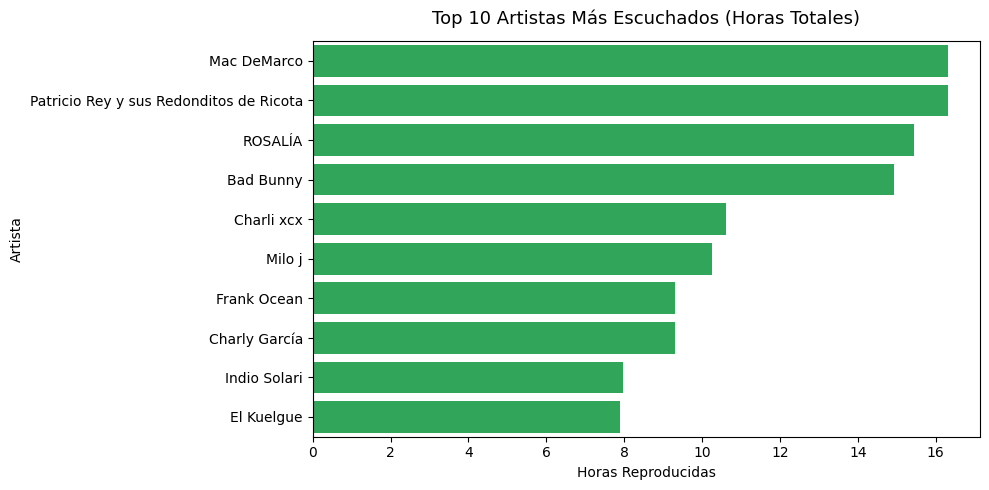

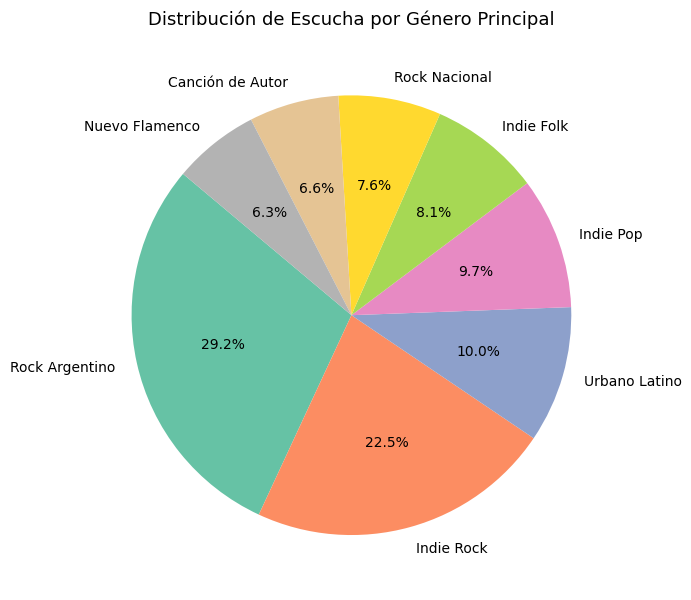

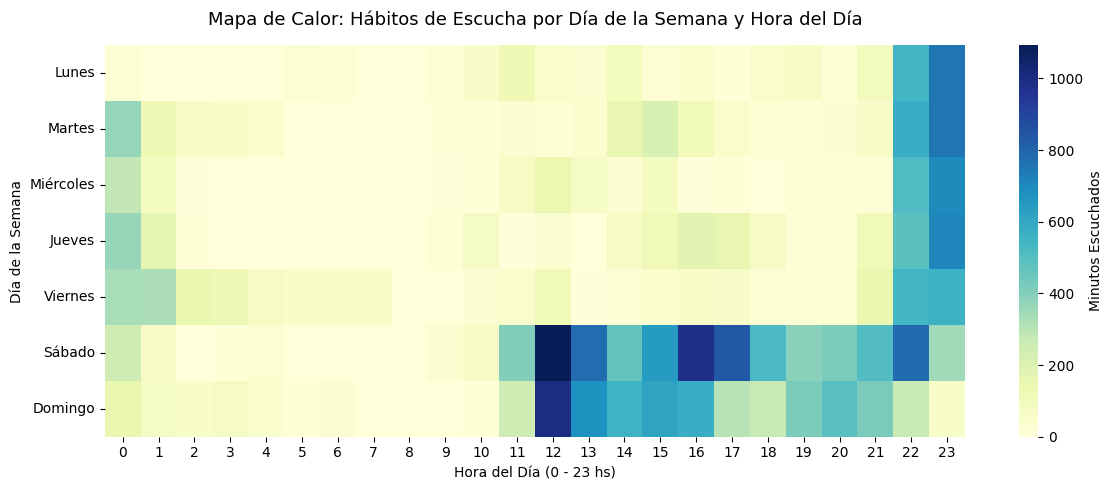

In [40]:
# ==========================================
# VISUALIZACIONES
# ==========================================

COLOR_SPOTIFY = "#1DB954"

if not df_streaming.empty:
    # 1. Top 10 Artistas Más Escuchados (Color Unificado)
    top_artists = (
        df_streaming.groupby("artistName")["hoursPlayed"]
        .sum()
        .nlargest(10)
        .reset_index()
    )

    plt.figure(figsize=(10, 5))
    sns.barplot(
        data=top_artists,
        x="hoursPlayed",
        y="artistName",
        color=COLOR_SPOTIFY,  # Ahora se encuentra definida correctamente
    )
    plt.title(
        "Top 10 Artistas Más Escuchados (Horas Totales)", fontsize=13, pad=12
    )
    plt.xlabel("Horas Reproducidas", fontsize=10)
    plt.ylabel("Artista", fontsize=10)
    plt.tight_layout()
    plt.show()

    # 2. Distribución por Género Principal
    top_genres = genre_summary.head(8).reset_index()
    plt.figure(figsize=(7, 7))
    plt.pie(
        top_genres["horas_escuchadas"],
        labels=top_genres["genero_principal"],
        autopct="%1.1f%%",
        startangle=140,
        colors=sns.color_palette("Set2"),
    )
    plt.title(
        "Distribución de Escucha por Género Principal", fontsize=13, pad=12
    )
    plt.tight_layout()
    plt.show()

    # 3. Mapa de Calor (Día de la Semana vs Hora del Día)
    matriz_heatmap = (
        df_streaming.groupby(["dia_semana", "hour"], observed=False)[
            "minutesPlayed"
        ]
        .sum()
        .unstack(fill_value=0)
    )
    plt.figure(figsize=(12, 5))
    sns.heatmap(
        matriz_heatmap,
        cmap="YlGnBu",
        annot=False,
        cbar_kws={"label": "Minutos Escuchados"},
    )
    plt.title(
        "Mapa de Calor: Hábitos de Escucha por Día de la Semana y Hora del Día",
        fontsize=13,
        pad=15,
    )
    plt.xlabel("Hora del Día (0 - 23 hs)", fontsize=10)
    plt.ylabel("Día de la Semana", fontsize=10)
    plt.tight_layout()
    plt.show()

##GENERACIÓN DE CSVs

In [41]:
# ==========================================
# GENERACIÓN Y EXPORTACIÓN DE CSVS
# ==========================================
# 1. Dataset Streaming Enriquecido Base
if not df_streaming.empty:
    df_streaming.to_csv(
        "streaming_history_enriquecido.csv", index=False, encoding="utf-8-sig"
    )

if not df_library.empty:
    df_library.to_csv(
        "library_enriquecida.csv", index=False, encoding="utf-8-sig"
    )

# 2. KPIs Generales por Género
if "genre_summary" in locals() and not genre_summary.empty:
    genre_summary.reset_index().to_csv(
        "kpi_generos_summary.csv", index=False, encoding="utf-8-sig"
    )

# 3. Resumen Diario por Género
if not df_streaming.empty:
    resumen_generos_diario = (
        df_streaming.groupby(
            ["Fecha", "genero_principal", "generos_secundarios"],
            as_index=False,
        )
        .agg(
            cantidad_reproducciones=("trackName", "count"),
            msPlayed=("msPlayed", "sum"),
            minutosPlayed=("minutesPlayed", "sum"),
        )
        .sort_values(by=["Fecha", "msPlayed"], ascending=[True, False])
    )
    resumen_generos_diario.to_csv(
        "Resumen_Generos_Diario.csv", index=False, encoding="utf-8-sig"
    )

    # 4. Matriz Diaria Top 10 Artistas
    top_10_artistas = (
        df_streaming.groupby("artistName")["msPlayed"]
        .sum()
        .nlargest(10)
        .index.tolist()
    )
    matriz_top10 = (
        df_streaming[df_streaming["artistName"].isin(top_10_artistas)]
        .pivot_table(
            index="Fecha",
            columns="artistName",
            values="msPlayed",
            aggfunc="sum",
        )
        .fillna(0)
    )
    matriz_top10["Total_msPlayed_Diario"] = matriz_top10.sum(axis=1)
    matriz_top10.reset_index().to_csv(
        "Matriz_Diaria_Top10_Artistas.csv", index=False, encoding="utf-8-sig"
    )

# 5. Ranking de Librería Cruzado con Streaming
if not df_library.empty:
    art_col = (
        "artist"
        if "artist" in df_library.columns
        else ("artistName" if "artistName" in df_library.columns else None)
    )

    if art_col:
        ranking_lib = (
            df_library.groupby(
                [art_col, "genero_principal", "generos_secundarios"],
                as_index=False,
            )
            .agg(canciones_guardadas=("track", "count"))
            .rename(columns={art_col: "artistName"})
        )
        stats_stream = df_streaming.groupby("artistName", as_index=False).agg(
            reproducciones_totales=("trackName", "count"),
            msPlayed_totales=("msPlayed", "sum"),
            minutosPlayed_totales=("minutesPlayed", "sum"),
        )
        ranking_completo = pd.merge(
            ranking_lib, stats_stream, on="artistName", how="left"
        ).fillna(0)
        ranking_completo = ranking_completo.sort_values(
            by=["canciones_guardadas", "reproducciones_totales"],
            ascending=[False, False],
        )
        ranking_completo.to_csv(
            "Ranking_Libreria_Artistas.csv", index=False, encoding="utf-8-sig"
        )

# 6. CSVs para Mapa de Calor (Formatos Tabla y Matriz)
if not df_streaming.empty:
    heatmap_data = (
        df_streaming.groupby(["dia_semana", "hour"])
        .agg(
            cantidad_reproducciones=("trackName", "count"),
            msPlayed=("msPlayed", "sum"),
            minutosPlayed=("minutesPlayed", "sum"),
        )
        .reset_index()
    )

    heatmap_data.to_csv(
        "Heatmap_Dia_Hora_Streaming.csv", index=False, encoding="utf-8-sig"
    )

    matriz_heatmap_export = heatmap_data.pivot(
        index="dia_semana", columns="hour", values="minutosPlayed"
    ).fillna(0)

    matriz_heatmap_export.to_csv(
        "Matriz_Heatmap_Dia_Hora.csv", encoding="utf-8-sig"
    )

print("=" * 50)
print("¡EXPORTACIÓN COMPLETADA CON ÉXITO!")
print("Se generaron todos los archivos CSV.")
print("=" * 50)

¡EXPORTACIÓN COMPLETADA CON ÉXITO!
Se generaron todos los archivos CSV.


/tmp/ipykernel_2444/457791554.py:97: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_streaming.groupby(["dia_semana", "hour"])


In [44]:
# ==========================================
# GENERACIÓN DE CSV: Resumen Mensual Top 10 Géneros
# ==========================================
if not df_streaming.empty:
    # 1. Crear la columna de Mes (Formato YYYY-MM)
    df_streaming["Mes"] = pd.to_datetime(df_streaming["endTime"]).dt.to_period(
        "M"
    )

    # 2. Identificar el Top 10 de géneros principales por tiempo total
    top_10_generos = (
        df_streaming.groupby("genero_principal")["msPlayed"]
        .sum()
        .nlargest(10)
        .index.tolist()
    )

    # 3. Filtrar df_streaming solo para el Top 10 de géneros
    df_top_generos = df_streaming[
        df_streaming["genero_principal"].isin(top_10_generos)
    ]

    # 4. Agrupar por Mes, Género Principal y Géneros Secundarios
    resumen_generos_mensual_top10 = (
        df_top_generos.groupby(
            ["Mes", "genero_principal", "generos_secundarios"], as_index=False
        )
        .agg(
            cantidad_reproducciones=("trackName", "count"),
            msPlayed=("msPlayed", "sum"),
            **{"Minutos escuchados": ("minutesPlayed", "sum")}
        )
        .sort_values(by=["Mes", "msPlayed"], ascending=[True, False])
    )

    # Convertir el periodo a string para una exportación limpia en CSV
    resumen_generos_mensual_top10["Mes"] = resumen_generos_mensual_top10[
        "Mes"
    ].astype(str)

    # 5. Exportar a CSV
    resumen_generos_mensual_top10.to_csv(
        "Resumen_Generos_Mensual.csv", index=False, encoding="utf-8-sig"
    )